# TCC – Notebook Público de Reprodução

Este notebook reproduz a análise final do trabalho **“Precificação dinâmica de estúdios por temporada com algoritmos multi-armed bandits”**.

Objetivos deste material:
- reconstruir a base analítica a partir dos arquivos brutos;
- reproduzir as tabelas e figuras centrais do TCC;
- treinar novamente o modelo final de demanda;
- reproduzir as simulações MAB nos cenários estacionário e multi-estação.

O foco aqui é **reprodutibilidade pública**. Por isso, foram mantidas apenas as células necessárias para seguir a lógica do trabalho final.


In [43]:
import importlib
from pathlib import Path
import json
import warnings

dependencias = [
    'pandas', 'numpy', 'seaborn', 'matplotlib', 'tqdm', 'factor_analyzer',
    'joblib', 'statsmodels', 'sklearn'
]

faltantes = []
for dependencia in dependencias:
    try:
        importlib.import_module(dependencia)
    except ModuleNotFoundError:
        faltantes.append(dependencia)

if faltantes:
    raise ModuleNotFoundError('Dependências ausentes: ' + ', '.join(faltantes))

BASE_DIR = Path.cwd()
warnings.filterwarnings('ignore')
print(f'Diretório de execução: {BASE_DIR}')


Diretório de execução: /Users/kleberabreu/Desktop/TCC/tcc-copy-note/Dados


In [44]:

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from datetime import timedelta
from tqdm import tqdm
import calendar
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import pairwise_distances
from scipy.stats import bartlett
from factor_analyzer.factor_analyzer import calculate_kmo
import joblib
import statsmodels.api as sm
from statsmodels.regression.mixed_linear_model import MixedLM
from sklearn.model_selection import train_test_split
import os
pd.set_option('display.max_columns', None)
sns.set(style='whitegrid')


import statsmodels.formula.api as smf
from sklearn.metrics import mean_absolute_error, mean_squared_error


## 1. Ingestão e filtro da amostra

Primeiro são lidos os arquivos `listings` dos quatro snapshots trimestrais. Em seguida aplica-se o recorte amostral do trabalho: estúdios/apartamentos compactos, `Entire home/apt`, até 3 hóspedes, no máximo 1 quarto, até 90 noites, `superhost` e presença nos quatro períodos.


In [45]:
# Lista de arquivos e datas correspondentes
listings = {
    'listings_jun24.csv.gz': 202406,
    'listings_set24.csv.gz': 202409,
    'listings_dez24.csv.gz': 202412,
    'listings_mar25.csv.gz': 202503,
}

# Lista de arquivos e datas correspondentes
calendars = {
    'calendar_jun24.csv.gz': 202406,
    'calendar_set24.csv.gz': 202409,
    'calendar_dez24.csv.gz': 202412,
    'calendar_mar25.csv.gz': 202503,
}


# Filtros e colunas relevantes
tipos_estudio = [
    'Entire condo', 'Entire rental unit', 'Entire loft', 'Entire place'
]


colunas_uteis = [
    'id', 'latitude', 'longitude', 'property_type', 'room_type',
    'accommodates', 'bedrooms', 'bathrooms', 'beds', 'amenities',
    'price', 'minimum_nights', 'maximum_nights',
    'number_of_reviews', 'reviews_per_month',
    'review_scores_rating', 'review_scores_accuracy', 'review_scores_cleanliness',
    'review_scores_checkin', 'review_scores_communication',
    'review_scores_location', 'review_scores_value',
    'neighbourhood_cleansed', 'host_total_listings_count'
]


# Ingestão da tabela `listings` com filtros para selecionar o tipo de imóvel alvo
dfs = []

for listing, anomes in listings.items():
    print(f"Lendo o arquivo: {listing}")
    df = pd.read_csv(listing, compression='gzip', low_memory=False)
    print(f"Total de linhas antes do filtro: {len(df)}")
    
    df_filtrado = df[
        (df['property_type'].isin(tipos_estudio)) &
        (df['room_type'] == 'Entire home/apt') &
        (df['bedrooms'] <= 1) &
        (df['accommodates'] <= 3) &
        (df['maximum_nights'] <= 90) &
        (df['host_is_superhost'] == 't') &
        (df['beds'] <= 3) 
    ].copy()
    
    print(f"Linhas após filtro: {len(df_filtrado)}")

    df_filtrado['anomes_ref'] = anomes
    
    df_final = df_filtrado[colunas_uteis + ['anomes_ref']]

    dfs.append(df_final)
    print(f"Arquivo '{listing}' processado com sucesso.")
    print("")

# Empilha todos os datasets 'listing'
df_completo = pd.concat(dfs, ignore_index=True)
print(f"Total combinado de linhas dos 4 arquivos: {len(df_completo)}")



# Selecionando apenas imóveis presentes em todos os períodos da análise

# Verifica todos os períodos únicos
periodos = df_completo['anomes_ref'].unique()
print(f"Períodos encontrados: {periodos}")

# Encontra os IDs comuns a todos os períodos
ids_comuns = set(df_completo[df_completo['anomes_ref'] == periodos[0]]['id'])

for periodo in periodos[1:]:
    ids_do_mes = set(df_completo[df_completo['anomes_ref'] == periodo]['id'])
    ids_comuns = ids_comuns.intersection(ids_do_mes)

    
print(f"Total de IDs presentes em todos os períodos: {len(ids_comuns)}")

# Filtra o dataframe completo
# Aqui estamos filtrando apenas os imóveis presentes em todos os períodos de estudo para garantir que as oscilações de preço são comparáveis entre os períodos analisados.
df_final_listings = df_completo[df_completo['id'].isin(ids_comuns)].copy()




# Bairro – one‑hot (mantendo top N bairros, agrupando o resto)
top_n = 5
top_neigh = df_final_listings['neighbourhood_cleansed'].value_counts().nlargest(top_n).index
df_final_listings['neighbourhood_enc'] = df_final_listings['neighbourhood_cleansed'].where(df_final_listings['neighbourhood_cleansed'].isin(top_neigh), 'Other')

# Organiza nome dos bairros
df_final_listings['neighbourhood_cleansed'] = df_final_listings['neighbourhood_cleansed'].str.lower().str.replace(" ", "_")
df_final_listings['neighbourhood_enc'] = df_final_listings['neighbourhood_enc'].str.lower().str.replace(" ", "_")

print(df_final_listings['neighbourhood_enc'].value_counts())



Lendo o arquivo: listings_jun24.csv.gz
Total de linhas antes do filtro: 34664
Linhas após filtro: 1030
Arquivo 'listings_jun24.csv.gz' processado com sucesso.

Lendo o arquivo: listings_set24.csv.gz
Total de linhas antes do filtro: 36967
Linhas após filtro: 1145
Arquivo 'listings_set24.csv.gz' processado com sucesso.

Lendo o arquivo: listings_dez24.csv.gz
Total de linhas antes do filtro: 39499
Linhas após filtro: 1276
Arquivo 'listings_dez24.csv.gz' processado com sucesso.

Lendo o arquivo: listings_mar25.csv.gz
Total de linhas antes do filtro: 42013
Linhas após filtro: 1402
Arquivo 'listings_mar25.csv.gz' processado com sucesso.

Total combinado de linhas dos 4 arquivos: 4853
Períodos encontrados: [202406 202409 202412 202503]
Total de IDs presentes em todos os períodos: 571
copacabana     986
other          577
ipanema        255
leblon         184
centro         182
jacarepaguá    100
Name: neighbourhood_enc, dtype: int64


## 2. Construção da variável-alvo

A ocupação trimestral prospectiva é derivada dos arquivos `calendar`, usando as janelas `m+1`, `m+2` e `m+3` a partir de cada snapshot.


In [46]:
# Importando tabelas `calendar`
# Filtra apenas janela de 90 dias após o mês de referência para posteriorment construir uma proxy de ocupação trimestral.
# A data base da informação do mês de referência é sempre o último dia do mês

dfs = []

# Cria um conjunto de IDs válidos para checagem rápida
ids_validos = set(df_final_listings['id'].astype(int))

for calendar_path, anomes in calendars.items():
    print(f"Lendo o arquivo: {calendar_path}")
    
    # Leitura e preparação inicial
    df = pd.read_csv(calendar_path, compression='gzip', low_memory=False)
    total_linhas = len(df)
    df['anomes_ref'] = anomes

    # Converte colunas de data
    df['date'] = pd.to_datetime(df['date'])
    anomes_str = str(anomes)
    inicio_janela = pd.to_datetime(anomes_str + '01', format='%Y%m%d')
    fim_do_mes = inicio_janela + pd.offsets.MonthEnd(1)
    fim_janela = fim_do_mes + pd.Timedelta(days=90)

    # Filtra por data e por ID válido
    df_filtrado = df[
        (df['date'] >= inicio_janela) &
        (df['date'] <= fim_janela) &
        (df['listing_id'].astype(int).isin(ids_validos))
    ].copy()

    linhas_mantidas = len(df_filtrado)
    linhas_excluidas = total_linhas - linhas_mantidas

    print(f"Total de linhas lidas: {total_linhas}")
    print(f"Linhas mantidas dentro da janela e com ID válido: {linhas_mantidas}")
    print(f"Linhas excluídas por data ou ID fora da seleção: {linhas_excluidas}\n")

    dfs.append(df_filtrado)

# Junta todos os dados filtrados
df_completo_calendar = pd.concat(dfs, ignore_index=True)
print(f"Total combinado de linhas após filtro final: {len(df_completo_calendar)}")


# Cria janelas de oculapação a partir da tabela `calendar`

# Função auxiliar – devolve quantos dias (ou noites) tem o mês

tqdm.pandas()  # habilita progresso em pandas

def dias_no_mes(ano: int, mes: int, considerar_noites: bool = False) -> int:
    """
    Retorna a quantidade de dias do mês indicado.
    Se considerar_noites=True, devolve dias-1 (30 noites num mês de 31 dias).
    """
    qtd_dias = calendar.monthrange(ano, mes)[1]  # ex.: 31
    return qtd_dias - 1 if considerar_noites else qtd_dias


# Função principal de classificação

def classificar_por_diferenca(row, considerar_noites: bool = False):
    """
    Classifica cada linha como:
        'ref'  -> mês de referência     [0 .. dias_m   ]
        'm+1'  -> mês seguinte          [dias_m+1_anterior+1 .. soma1]
        'm+2'  -> segundo mês à frente  [...]
        'm+3'  -> terceiro mês à frente [...]
    utilizando a quantidade exata de dias (ou noites) de cada mês.
    """
    anomes = row['anomes_ref']        # formato 'YYYYMM' como string ou int
    data   = row['date']              # coluna já convertida p/ datetime64

    try:
        # Datas-limite para cada faixa
        ano_ref  = int(str(anomes)[:4])
        mes_ref  = int(str(anomes)[4:])

        # dias / noites de cada mês
        dias_m     = dias_no_mes(ano_ref, mes_ref, considerar_noites)
        dias_m1    = dias_no_mes(*divmod(mes_ref, 12)) if mes_ref != 12 else dias_no_mes(ano_ref+1, 1, considerar_noites)
        dias_m2    = dias_no_mes(*divmod((mes_ref % 12) + 1, 12)) if mes_ref != 11 else dias_no_mes(ano_ref+1, 2, considerar_noites)
        dias_m3    = dias_no_mes(*divmod((mes_ref % 12) + 2, 12)) if mes_ref >= 10 else dias_no_mes(ano_ref, mes_ref+3, considerar_noites)

        # início do mês de referência
        inicio_ref = pd.to_datetime(f"{ano_ref}{mes_ref:02d}01", format='%Y%m%d')
        dias_diff  = (data - inicio_ref).days

        # Classificação por faixa
        if 0 <= dias_diff <= dias_m - 1:
            return 'ref'
        elif dias_m <= dias_diff <= dias_m + dias_m1 - 1:
            return 'm+1'
        elif dias_m + dias_m1 <= dias_diff <= dias_m + dias_m1 + dias_m2 - 1:
            return 'm+2'
        elif dias_m + dias_m1 + dias_m2 <= dias_diff <= dias_m + dias_m1 + dias_m2 + dias_m3 - 1:
            return 'm+3'
        else:
            return None

    except Exception as e:
        # Se algo der errado (data inválida, etc.)
        return None


# Aplicação no DataFrame

df_completo_calendar['janela_flag'] = df_completo_calendar.progress_apply(
    classificar_por_diferenca, axis=1, considerar_noites=True 
)

# Distribuição resultante

print(df_completo_calendar['janela_flag'].value_counts(dropna=False))

# Filtra apenas as janelas m+1, m+2 e m+3
df_completo_calendar = df_completo_calendar[
    df_completo_calendar['janela_flag'].isin(['m+1', 'm+2', 'm+3'])
].copy()

print(df_completo_calendar['janela_flag'].value_counts(dropna=False))


# Cria coluna binária de ocupação (1 = ocupado, 0 = disponível)
df_completo_calendar['is_occupied'] = (df_completo_calendar['available'] == 'f').astype(int)

# Agrupa para contar ocupações por ID e mês de referência, separando por janela (ref, m+1, m+2, m+3)
ocupacao = (
    df_completo_calendar.groupby(['listing_id', 'anomes_ref', 'janela_flag'])['is_occupied']
    .sum()
    .reset_index()
    .pivot(index=['listing_id', 'anomes_ref'], columns='janela_flag', values='is_occupied')
    .fillna(0)
    .astype(int)
)

## Renomeia colunas para o padrão desejado
ocupacao.columns = [f'ocupacy_{col}' for col in ocupacao.columns]

## Transforma novamente em dataframe plano
df_final_calendar= ocupacao.reset_index()

## Cria coluna de ocupação trimestral
df_final_calendar['total_ocupacy_3'] = df_final_calendar['ocupacy_m+1']+df_final_calendar['ocupacy_m+2']+df_final_calendar['ocupacy_m+3']

## Visualização rápida
print(df_final_calendar.head())
df_final_calendar.count()


Lendo o arquivo: calendar_jun24.csv.gz
Total de linhas lidas: 12652371
Linhas mantidas dentro da janela e com ID válido: 53261
Linhas excluídas por data ou ID fora da seleção: 12599110

Lendo o arquivo: calendar_set24.csv.gz
Total de linhas lidas: 13493052
Linhas mantidas dentro da janela e com ID válido: 54549
Linhas excluídas por data ou ID fora da seleção: 13438503

Lendo o arquivo: calendar_dez24.csv.gz
Total de linhas lidas: 14416839
Linhas mantidas dentro da janela e com ID válido: 53871
Linhas excluídas por data ou ID fora da seleção: 14362968

Lendo o arquivo: calendar_mar25.csv.gz
Total de linhas lidas: 15334969
Linhas mantidas dentro da janela e com ID válido: 58228
Linhas excluídas por data ou ID fora da seleção: 15276741

Total combinado de linhas após filtro final: 219909


100%|████████████████████████████████| 219909/219909 [00:15<00:00, 14129.05it/s]

m+2     70233
m+1     69091
m+3     66807
ref     12065
None     1713
Name: janela_flag, dtype: int64
m+2    70233
m+1    69091
m+3    66807
Name: janela_flag, dtype: int64
   listing_id  anomes_ref  ocupacy_m+1  ocupacy_m+2  ocupacy_m+3  \
0       25026      202406            6            0           13   
1       25026      202409           13           27            8   
2       25026      202412           29           21            6   
3       25026      202503           31            5            0   
4       35764      202406           25           24           17   

   total_ocupacy_3  
0               19  
1               48  
2               56  
3               36  
4               66  


listing_id         2284
anomes_ref         2284
ocupacy_m+1        2284
ocupacy_m+2        2284
ocupacy_m+3        2284
total_ocupacy_3    2284
dtype: int64

## 3. Tratamento e engenharia de variáveis

Aqui são feitos o merge das bases, o tratamento de extremos por winsorização, transformações logarítmicas e a criação das variáveis de contexto competitivo e sazonalidade.


In [47]:
# 1. Merge dos dados com tratamento de conflitos de nomes
# Padroniza o tipo da chave de merge


for df, id_col in [(df_final_calendar, 'listing_id'),
                   (df_final_listings, 'id')]:
    
    # tira espaços e converte para inteiro
    df[id_col] = (df[id_col]
                  .astype(str)      # garante string
                  .str.strip()      # remove espaços
                  .str.lstrip('0')  # tira zeros à esquerda (se houver)
                  .astype(int)      # volta para int padronizado
                 )

# mesmo tratamento para anomes_ref
for df in (df_final_calendar, df_final_listings):
    df['anomes_ref'] = (df['anomes_ref']
                        .astype(str)
                        .str.strip()
                        .str.replace('[^0-9]', '', regex=True)  # deixa só números
                       ).astype(int)  # ex.: 202405


df_final_calendar['anomes_ref'] = df_final_calendar['anomes_ref'].astype(str)
df_final_listings['anomes_ref'] = df_final_listings['anomes_ref'].astype(str)


df_merged = df_final_calendar.merge(
    df_final_listings,
    how='inner',
    left_on=['listing_id', 'anomes_ref'],
    right_on=['id', 'anomes_ref'],
    suffixes=('_calendar', '_listings')  # Evita conflitos se houver colunas com nomes iguais
)


#trata campos de preço
df_merged['price'] = df_merged['price'].replace('[\$,]', '', regex=True).astype(float)
df_merged.head()


variaveis_checagem = [
    'price',
    'review_scores_rating',
    'review_scores_accuracy',
    'review_scores_cleanliness',
    'review_scores_checkin',
    'review_scores_communication',
    'review_scores_location',
    'review_scores_value',
    'number_of_reviews',
    'reviews_per_month',
    'host_total_listings_count',
    'total_ocupacy_3',
    'ocupacy_m+1',
    'ocupacy_m+2',
    'ocupacy_m+3',
]

# Corrige o tipo de price (se necessário)

df_final_tratado = df_merged.copy()

if df_final_tratado['price'].dtype == 'object':
    df_final_tratado['price'] = (
        df_final_tratado['price']
        .replace('[\$,]', '', regex=True)
        .astype(float)
    )
    

for var in variaveis_checagem:
    if var in df_final_tratado.columns:
        df_final_tratado[var] = pd.to_numeric(df_final_tratado[var], errors='coerce')

print("\n 1. Tipos de dados:")
print(df_final_tratado.dtypes)

print("\n 2. Verificação de valores nulos por coluna:")
nulos = df_final_tratado.isnull().sum()
print(nulos[nulos > 0].sort_values(ascending=False))

print("\n 3. Estatísticas descritivas (numéricas):")
print(df_final_tratado.describe(include='number'))

def detectar_outliers_iqr(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lim_inf = Q1 - 1.5 * IQR
    lim_sup = Q3 + 1.5 * IQR
    return (series < lim_inf) | (series > lim_sup)

print("\n🚨 4. Possíveis outliers (via IQR):")
for var in variaveis_checagem:
    if var in df_final_tratado.columns:
        outliers = detectar_outliers_iqr(df_final_tratado[var])
        total_outliers = outliers.sum()
        perc = (total_outliers / len(df_final_tratado)) * 100
        print(f"🔸 {var}: {total_outliers} possíveis outliers ({perc:.2f}%)")


# Tratamento de Outlayers

df_tratando_outlayers = df_final_tratado.copy()

# Funções auxiliares
def winsorize_series(s, lower_q=0.01, upper_q=0.99):
    """
    Clipa a série nos quantis indicados (winsorização).
    Retorna a série já clipada.
    """
    lower, upper = s.quantile([lower_q, upper_q])
    return s.clip(lower, upper)



# Limpeza e tratamento de variáveis numéricas

# PRICE

if df_tratando_outlayers['price'].dtype == 'object':
    ddf_tratando_outlayersf['price'] = (
        df_tratando_outlayers['price']
        .replace('[\$,]', '', regex=True)
        .astype(float)
    )

# Winsoriza p01–p99
df_tratando_outlayers['price_w'] = winsorize_series(df_tratando_outlayers['price'], 0.01, 0.99)

# Transformação em log
df_tratando_outlayers['log_price'] = np.log1p(df_tratando_outlayers['price_w'])


# REVIEW SCORES
# Converter review_scores_* para escala 0-100 
score_cols = ['review_scores_rating', 
    'review_scores_accuracy', 
    'review_scores_cleanliness',
    'review_scores_checkin', 
    'review_scores_communication',
    'review_scores_location', 
    'review_scores_value']

for col in score_cols:
    # se a maior nota for <=5, presumimos escala 0-5 e multiplicamos
    if df_tratando_outlayers[col].max(skipna=True) <= 5:
        df_tratando_outlayers[col] = df_tratando_outlayers[col] * 20   # 4,75 → 95

# Transformar 0 em NaN (sem avaliação)
df_tratando_outlayers[score_cols] = df_tratando_outlayers[score_cols].replace(0, np.nan)

# Winsorizar parte inferior (hard-floor 40)
df_tratando_outlayers[score_cols] = df_tratando_outlayers[score_cols].clip(lower=40, upper=100)

    
# NUMBER OF REVIEWS & REVIEWS PER MONTH
for col in ['number_of_reviews', 'reviews_per_month']:
    if col in df_tratando_outlayers.columns:
        p99 = df_tratando_outlayers[col].quantile(0.99)
        df_tratando_outlayers[f'{col}_w']   = df_tratando_outlayers[col].clip(upper=p99)
        df_tratando_outlayers[f'log_{col}'] = np.log1p(df_tratando_outlayers[f'{col}_w'])

## HOST_TOTAL_LISTINGS_COUNT
if 'host_total_listings_count' in df_tratando_outlayers.columns:
    p99 = df_tratando_outlayers['host_total_listings_count'].quantile(0.99)
    df_tratando_outlayers['host_total_listings_count_w']   = df_tratando_outlayers['host_total_listings_count'].clip(upper=p99)
    df_tratando_outlayers['log_host_total_listings_count'] = np.log1p(df_tratando_outlayers['host_total_listings_count_w'])
    df_tratando_outlayers['host_pro'] = (df_tratando_outlayers['host_total_listings_count'] >= 5).astype(int)

print("Done!")

#Cosntroção de outras variáveis de interesse

df_feature_buinding = df_tratando_outlayers.copy()

df_feature_buinding['price_pct_bairro'] = df_feature_buinding.groupby('neighbourhood_enc')['price'] \
                           .rank(pct=True)
median_price = df_feature_buinding.groupby('neighbourhood_enc')['price'].transform('median')
df_feature_buinding['discount_vs_median'] = (df_feature_buinding['price'] - median_price) / median_price

# Ex: ocupação média trimestral
bairro_mean_ocup = df_feature_buinding.groupby('neighbourhood_enc')['total_ocupacy_3'].transform('mean')
df_feature_buinding['bairro_mean_ocup'] = bairro_mean_ocup


# Criação das variáveis de estação com base em anomes_ref
def mapear_estacao(anomes):
    mes = int(str(anomes)[4:6])
    if mes in [6, 7, 8]:
        return "inverno"
    elif mes in [9, 10, 11]:
        return "primavera"
    elif mes in [12, 1, 2]:
        return "verao"
    else:
        return "outono"

df_feature_buinding["estacao"] = df_feature_buinding["anomes_ref"].apply(mapear_estacao)



 1. Tipos de dados:
listing_id                       int64
anomes_ref                      object
ocupacy_m+1                      int64
ocupacy_m+2                      int64
ocupacy_m+3                      int64
total_ocupacy_3                  int64
id                               int64
latitude                       float64
longitude                      float64
property_type                   object
room_type                       object
accommodates                     int64
bedrooms                       float64
bathrooms                      float64
beds                           float64
amenities                       object
price                          float64
minimum_nights                   int64
maximum_nights                   int64
number_of_reviews                int64
reviews_per_month              float64
review_scores_rating           float64
review_scores_accuracy         float64
review_scores_cleanliness      float64
review_scores_checkin          float64
revi

## 4. Sumários descritivos alinhados ao TCC

As tabelas abaixo reproduzem os principais números descritivos discutidos no texto final do trabalho.


In [48]:
estatisticas_ocupacao = pd.DataFrame({
    'metrica': ['media_dias', 'mediana_dias', 'desvio_padrao_dias', 'ocupacao_zero_pct'],
    'valor': [
        df_feature_buinding['total_ocupacy_3'].mean(),
        df_feature_buinding['total_ocupacy_3'].median(),
        df_feature_buinding['total_ocupacy_3'].std(),
        (df_feature_buinding['total_ocupacy_3'].eq(0).mean() * 100),
    ]
})

bairros_artigo = ['copacabana', 'ipanema', 'leblon', 'centro', 'jacarepaguá', 'barra_da_tijuca', 'botafogo', 'flamengo']
tabela_2 = (
    df_feature_buinding.groupby('neighbourhood_cleansed')
    .agg(
        Obs=('listing_id', 'size'),
        Preco_mediano=('price', 'median'),
        Ocupacao_media=('total_ocupacy_3', 'mean')
    )
)
tabela_2 = tabela_2.loc[[b for b in bairros_artigo if b in tabela_2.index]].copy()
outros = df_feature_buinding[~df_feature_buinding['neighbourhood_cleansed'].isin(bairros_artigo)]
tabela_2.loc['outros_(24_bairros)'] = {
    'Obs': len(outros),
    'Preco_mediano': np.nan,
    'Ocupacao_media': np.nan,
}
tabela_2['Pct_amostra'] = tabela_2['Obs'] / len(df_feature_buinding) * 100
tabela_2.index = [
    idx.replace('_', ' ').title().replace('Da Tijuca', 'da Tijuca').replace('Outros (24 Bairros)', 'Outros (24 bairros)')
    for idx in tabela_2.index
]
tabela_2 = tabela_2[['Obs', 'Pct_amostra', 'Preco_mediano', 'Ocupacao_media']].round(1)

tabela_3 = (
    df_feature_buinding.groupby('estacao')['total_ocupacy_3']
    .agg(['mean', 'median', 'std', 'count'])
    .rename(columns={'mean': 'media_dias', 'median': 'mediana_dias', 'std': 'desvio_padrao', 'count': 'obs'})
    .round(1)
)

print('Estatísticas da variável-alvo:')
display(estatisticas_ocupacao.round(2))
print('\nTabela 2 — distribuição geográfica da amostra:')
display(tabela_2)
print('\nTabela 3 — ocupação média por estação:')
display(tabela_3)


Estatísticas da variável-alvo:


,metrica,valor
0,media_dias,34.60
1,mediana_dias,31.00
2,desvio_padrao_dias,23.71
3,ocupacao_zero_pct,4.20



Tabela 2 — distribuição geográfica da amostra:


,Obs,Pct_amostra,Preco_mediano,Ocupacao_media
Copacabana,986,43.2,266.5,35.1
Ipanema,255,11.2,368.0,37.7
Leblon,184,8.1,542.0,34.5
Centro,182,8.0,170.5,28.1
Jacarepaguá,100,4.4,184.0,28.0
Barra da Tijuca,96,4.2,390.0,30.2
Botafogo,80,3.5,254.0,46.7
Flamengo,71,3.1,215.0,45.7
Outros (24 bairros),330,14.4,NaN,NaN



Tabela 3 — ocupação média por estação:


,media_dias,mediana_dias,desvio_padrao,obs
estacao,,,,
inverno,28.2,24.0,22.1,571
outono,36.0,32.0,23.1,571
primavera,31.1,28.0,24.3,571
verao,43.1,44.0,22.7,571


## 5. Figura 1 — Histogramas antes e depois do tratamento


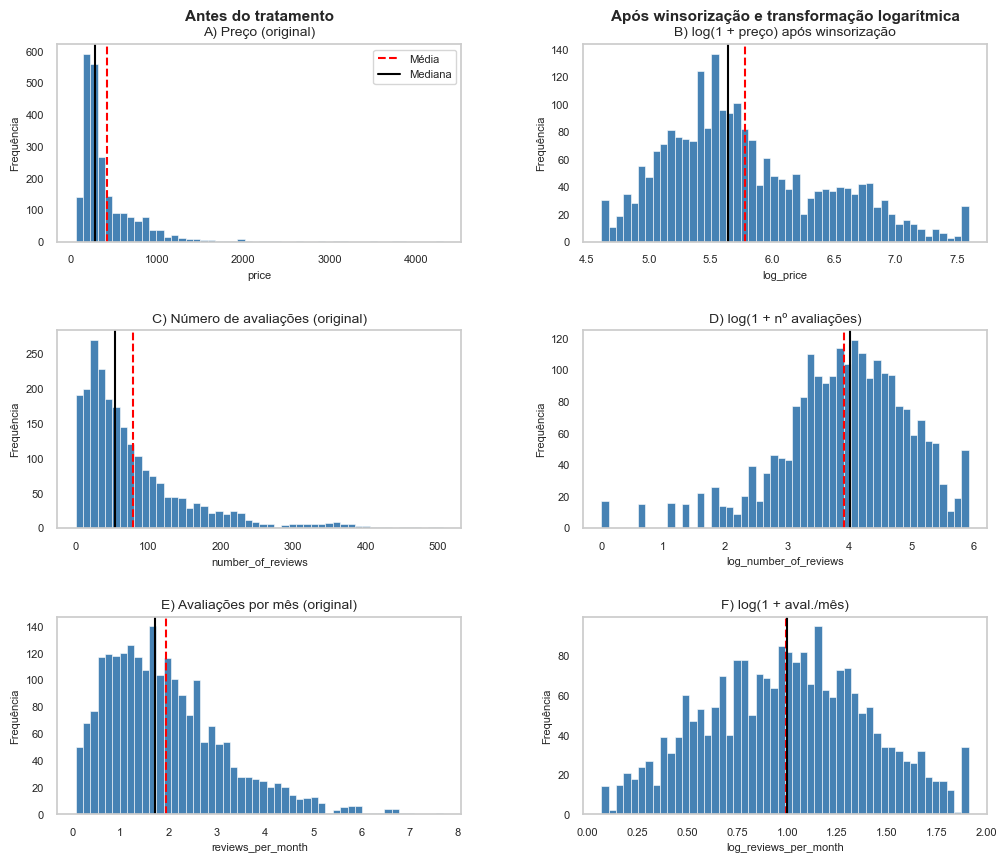

Figuras salvas: Histogramas Antes e depois.png e figura1_histogramas_antes_depois.png


In [49]:
import string

pares = [
    {
        'antes_col': 'price',
        'depois_col': 'log_price',
        'titulo_antes': 'Preço (original)',
        'titulo_depois': 'log(1 + preço) após winsorização',
    },
    {
        'antes_col': 'number_of_reviews',
        'depois_col': 'log_number_of_reviews',
        'titulo_antes': 'Número de avaliações (original)',
        'titulo_depois': 'log(1 + nº avaliações)',
    },
    {
        'antes_col': 'reviews_per_month',
        'depois_col': 'log_reviews_per_month',
        'titulo_antes': 'Avaliações por mês (original)',
        'titulo_depois': 'log(1 + aval./mês)',
    },
]

# Letras A → F
labels = list(string.ascii_uppercase)

fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(12, 10))
fig.subplots_adjust(hspace=0.45, wspace=0.3)

for i, par in enumerate(pares):
    for j, (col, titulo) in enumerate([
        (par['antes_col'], par['titulo_antes']),
        (par['depois_col'], par['titulo_depois']),
    ]):
        ax = axes[i][j]

        # Índice global (0 a 5)
        idx_global = i * 2 + j
        label = labels[idx_global]

        df_src = df_merged if j == 0 else df_feature_buinding
        dados = df_src[col].dropna()

        ax.hist(
            dados,
            bins=50,
            color='steelblue',
            edgecolor='white',
            linewidth=0.4
        )

        ax.axvline(
            dados.mean(),
            color='red',
            linestyle='--',
            linewidth=1.5,
            label='Média'
        )

        ax.axvline(
            dados.median(),
            color='black',
            linestyle='-',
            linewidth=1.5,
            label='Mediana'
        )

        # 👇 Aqui está o ajuste principal
        ax.set_title(
            f"{label}) {titulo}",
            fontsize=10,
            fontweight='normal',
            pad=6
        )

        ax.set_xlabel(col, fontsize=8)
        ax.set_ylabel('Frequência', fontsize=8)
        ax.tick_params(labelsize=8)
        ax.grid(False)

        if idx_global == 0:
            ax.legend(fontsize=8)

# Cabeçalhos das colunas
axes[0][0].annotate(
    'Antes do tratamento',
    xy=(0.5, 1.12),
    xycoords='axes fraction',
    ha='center',
    fontsize=11,
    fontweight='bold'
)

axes[0][1].annotate(
    'Após winsorização e transformação logarítmica',
    xy=(0.5, 1.12),
    xycoords='axes fraction',
    ha='center',
    fontsize=11,
    fontweight='bold'
)

# Salvando
plt.savefig(
    'Histogramas Antes e depois.png',
    dpi=200,
    bbox_inches='tight',
    facecolor='white'
)

plt.savefig(
    'figura1_histogramas_antes_depois.png',
    dpi=200,
    bbox_inches='tight',
    facecolor='white'
)

plt.show()

print('Figuras salvas: Histogramas Antes e depois.png e figura1_histogramas_antes_depois.png')

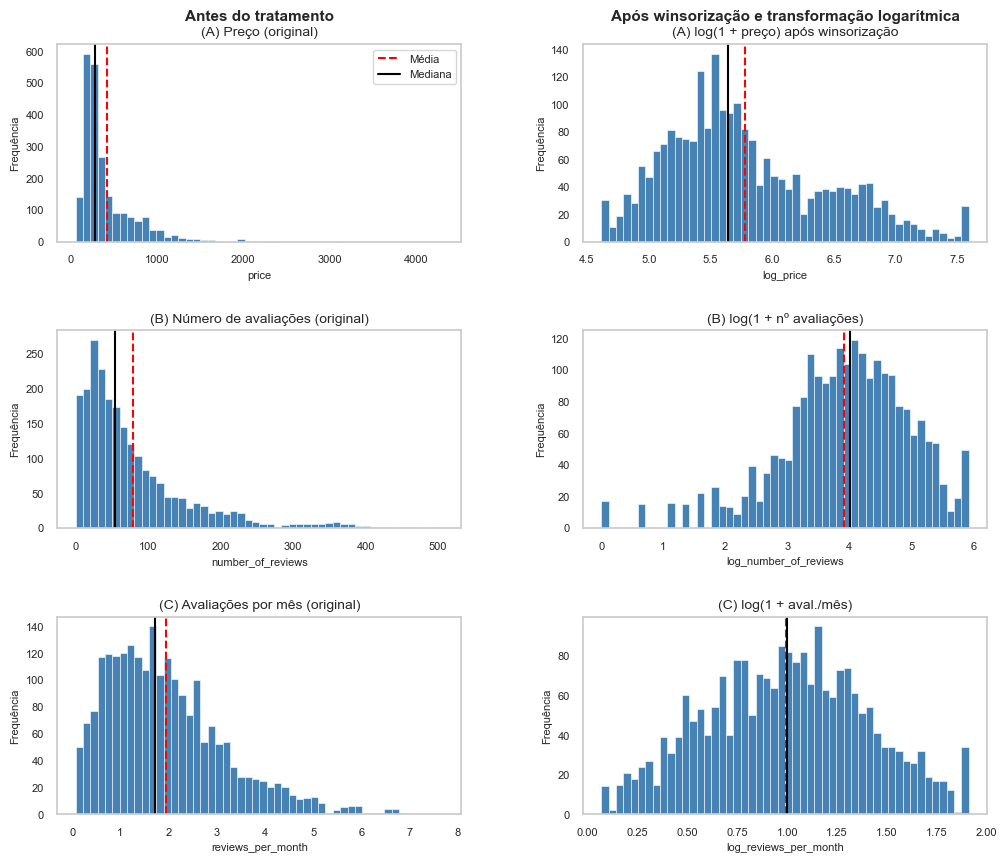

Figuras salvas: Histogramas Antes e depois.png e figura1_histogramas_antes_depois.png


In [50]:
pares = [
    {
        'label': 'A',
        'antes_col': 'price',
        'depois_col': 'log_price',
        'titulo_antes': 'Preço (original)',
        'titulo_depois': 'log(1 + preço) após winsorização',
    },
    {
        'label': 'B',
        'antes_col': 'number_of_reviews',
        'depois_col': 'log_number_of_reviews',
        'titulo_antes': 'Número de avaliações (original)',
        'titulo_depois': 'log(1 + nº avaliações)',
    },
    {
        'label': 'C',
        'antes_col': 'reviews_per_month',
        'depois_col': 'log_reviews_per_month',
        'titulo_antes': 'Avaliações por mês (original)',
        'titulo_depois': 'log(1 + aval./mês)',
    },
]

fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(12, 10))
fig.subplots_adjust(hspace=0.45, wspace=0.3)

for i, par in enumerate(pares):
    for j, (col, titulo) in enumerate([
        (par['antes_col'], par['titulo_antes']),
        (par['depois_col'], par['titulo_depois']),
    ]):
        ax = axes[i][j]
        df_src = df_merged if j == 0 else df_feature_buinding
        dados = df_src[col].dropna()
        ax.hist(dados, bins=50, color='steelblue', edgecolor='white', linewidth=0.4)
        ax.axvline(dados.mean(), color='red', linestyle='--', linewidth=1.5, label='Média')
        ax.axvline(dados.median(), color='black', linestyle='-', linewidth=1.5, label='Mediana')
        ax.set_title(f"({par['label']}) {titulo}", fontsize=10, fontweight='normal', pad=6)
        ax.set_xlabel(col, fontsize=8)
        ax.set_ylabel('Frequência', fontsize=8)
        ax.tick_params(labelsize=8)
        ax.grid(False)
        if i == 0 and j == 0:
            ax.legend(fontsize=8)

axes[0][0].annotate('Antes do tratamento', xy=(0.5, 1.12), xycoords='axes fraction', ha='center', fontsize=11, fontweight='bold')
axes[0][1].annotate('Após winsorização e transformação logarítmica', xy=(0.5, 1.12), xycoords='axes fraction', ha='center', fontsize=11, fontweight='bold')
plt.savefig('Histogramas Antes e depois.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.savefig('figura1_histogramas_antes_depois.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()
print('Figuras salvas: Histogramas Antes e depois.png e figura1_histogramas_antes_depois.png')


## 6. PCA para consolidação dos indicadores de qualidade


review_scores_rating     : -0.45
review_scores_accuracy   : -0.44
review_scores_cleanliness: -0.41
review_scores_checkin    : -0.35
review_scores_communication: -0.38
review_scores_value      : -0.41
{'bartlett_statistic': 2116.691427670131, 'bartlett_p_value': 0.0, 'kmo_score': 0.8816989859557294, 'pca_pipeline_path': 'pipeline_quality_score.pkl', 'correlacao_imagem': 'correlacao_subnotas.png', 'variancia_explicada': 0.647111021469792}


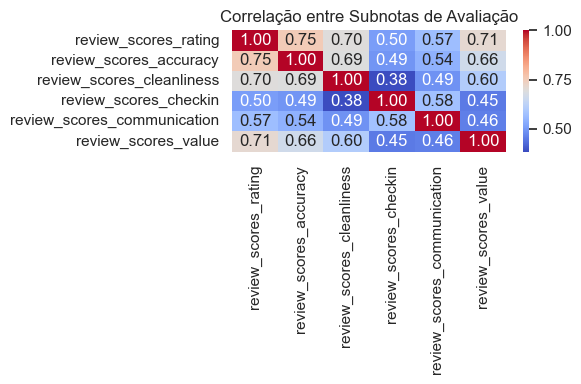

In [51]:
# Consolidando Scores (com excessão da localização) em componente PCA
# Subscores que serão usados na PCA

dt_pca = df_feature_buinding.copy()

sub_scores = [
    'review_scores_rating',
    'review_scores_accuracy',
    'review_scores_cleanliness',
    'review_scores_checkin',
    'review_scores_communication',
    'review_scores_value'
]


# Filtra as colunas relevantes
df_scores = dt_pca[sub_scores]

# -----------------------------
# Avaliações para PCA
# -----------------------------

# Correlação entre variáveis
cor_matrix = df_scores.corr()

# Teste de esfericidade de Bartlett (H0 = variáveis não correlacionadas)
bartlett_stat, bartlett_p = bartlett(*[df_scores[c].dropna() for c in sub_scores])

# KMO (Kaiser-Meyer-Olkin)
kmo_all, kmo_model = calculate_kmo(df_scores.dropna())




# -----------------------------
# 2. Pipeline PCA
# -----------------------------

# Imputação (mediana) + padronização + PCA(1)
pca_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=1, random_state=42))
])

# Ajuste
df_scores_nonan = df_scores.copy()
df_scores_nonan[sub_scores] = df_scores_nonan[sub_scores].fillna(df_scores.median())
quality_score = pca_pipeline.fit_transform(df_scores_nonan)

# Adiciona a nova coluna no df original
dt_pca['quality_score'] = quality_score

# Salva pipeline
joblib.dump(pca_pipeline, 'pipeline_quality_score.pkl')



# -----------------------------
# 4. Visualização
# -----------------------------
plt.figure(figsize=(6, 4))
sns.heatmap(cor_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlação entre Subnotas de Avaliação")
plt.tight_layout()
plt.savefig("correlacao_subnotas.png")

pca = joblib.load('pipeline_quality_score.pkl').named_steps['pca']

loadings = pca.components_[0]
for name, weight in zip(sub_scores, loadings):
    print(f"{name:25s}: {weight:+.2f}")


print({
    "bartlett_statistic": float(bartlett_stat),
    "bartlett_p_value": float(bartlett_p),
    "kmo_score": float(kmo_model),
    "pca_pipeline_path": "pipeline_quality_score.pkl",
    "correlacao_imagem": "correlacao_subnotas.png",
    "variancia_explicada": float(pca.explained_variance_ratio_[0])
})



dt_pca.to_csv("base_final_para_modelagem.csv" , index=False)


In [52]:
tabela_4 = pd.DataFrame({
    'tipo_nota': sub_scores,
    'loading_pc1': pca.components_[0]
})
tabela_4['loading_abs'] = tabela_4['loading_pc1'].abs()
tabela_4 = tabela_4.sort_values('loading_abs', ascending=False)
print('Tabela 4 — cargas fatoriais do primeiro componente principal:')
display(tabela_4[['tipo_nota', 'loading_pc1']].round(3))


Tabela 4 — cargas fatoriais do primeiro componente principal:


,tipo_nota,loading_pc1
0,review_scores_rating,-0.452
1,review_scores_accuracy,-0.441
5,review_scores_value,-0.413
2,review_scores_cleanliness,-0.411
4,review_scores_communication,-0.376
3,review_scores_checkin,-0.348


## 7. Seleção de variáveis e geração da base final

A base `base_final_para_modelagem.csv` será a entrada da modelagem de demanda e das simulações.


In [53]:
spearman_target = (
    dt_pca[[
        'log_price', 'discount_vs_median', 'quality_score', 'review_scores_location',
        'log_number_of_reviews', 'bairro_mean_ocup', 'log_host_total_listings_count',
        'accommodates', 'total_ocupacy_3'
    ]]
    .corr(method='spearman')['total_ocupacy_3']
    .drop('total_ocupacy_3')
    .sort_values(ascending=False)
)
tabela_5 = pd.DataFrame({
    'variavel': [
        'log_price', 'review_scores_location', 'log_number_of_reviews', 'bairro_mean_ocup',
        'estacao_verao', 'estacao_outono', 'estacao_primavera'
    ],
    'rho_spearman': [
        spearman_target.get('log_price', np.nan),
        spearman_target.get('review_scores_location', np.nan),
        spearman_target.get('log_number_of_reviews', np.nan),
        spearman_target.get('bairro_mean_ocup', np.nan),
        np.nan, np.nan, np.nan,
    ],
    'papel': [
        'Alavanca do MAB — variável de decisão',
        'Localização percebida pelo hóspede',
        'Popularidade e visibilidade',
        'Proxy de demanda local do bairro',
        'Sazonalidade — verão vs. inverno (ref.)',
        'Sazonalidade — outono vs. inverno (ref.)',
        'Sazonalidade — primavera vs. inverno (ref.)',
    ]
})
display(tabela_5.round(3))

print('Base final salva em base_final_para_modelagem.csv')


,variavel,rho_spearman,papel
0,log_price,0.116,Alavanca do MAB — variável de decisão
1,review_scores_location,0.102,Localização percebida pelo hóspede
2,log_number_of_reviews,0.182,Popularidade e visibilidade
3,bairro_mean_ocup,0.083,Proxy de demanda local do bairro
4,estacao_verao,NaN,Sazonalidade — verão vs. inverno (ref.)
5,estacao_outono,NaN,Sazonalidade — outono vs. inverno (ref.)
6,estacao_primavera,NaN,Sazonalidade — primavera vs. inverno (ref.)


Base final salva em base_final_para_modelagem.csv


## 8. Preparação da modelagem de demanda


In [54]:
# =============================================================
# CÉLULA 2 — Carga dos dados e criação da target
# =============================================================

# 1. Carregar a base final do ETL
df = pd.read_csv('base_final_para_modelagem.csv')
print(f"Shape original: {df.shape}")

# 2. Remover colunas de leakage (componentes da target)
leakage = ['ocupacy_m+1', 'ocupacy_m+2', 'ocupacy_m+3']
leakage_existentes = [c for c in leakage if c in df.columns]
df = df.drop(columns=leakage_existentes)
print(f"Colunas de leakage removidas: {leakage_existentes}")

# 3. Criar target: taxa de ocupação (0 a 1)
#    Janela trimestral tem até 91 dias (não 90!)
df['occ_rate'] = df['total_ocupacy_3'] / 91.0

# 4. Verificação rápida da target
print(f"\nShape após limpeza: {df.shape}")
print(f"\n--- Target (occ_rate) ---")
print(df['occ_rate'].describe())
print(f"\nMax = {df['occ_rate'].max():.4f}  (deve ser <= 1.0)")
print(f"Zeros = {(df['occ_rate'] == 0).sum()} ({(df['occ_rate'] == 0).sum()/len(df)*100:.1f}%)")

# =============================================================
# CÉLULA 3 — Seleção de features e encoding de estação
# =============================================================

# 1. Converter anomes_ref para string (será usado no split temporal)
df['anomes_ref'] = df['anomes_ref'].astype(str)


# 2. Features curadas (definidas na análise de correlação + PCA)
features_continuas = [
    'log_price',                       # alavanca do MAB
    'discount_vs_median',              # posição competitiva no bairro
    'quality_score',                   # PCA dos 6 subscores de review
    'review_scores_location',          # localização percebida (fora do PCA)
    'log_number_of_reviews',           # popularidade/visibilidade
    'bairro_mean_ocup',                # proxy de demanda do bairro
    'log_host_total_listings_count',   # perfil do host
    'accommodates',                    # capacidade do imóvel
]


# 3. Verificar se quality_score existe; se não, avisar
if 'quality_score' not in df.columns:
    print("⚠️  quality_score NÃO encontrado na base!")
    print("    Você precisa rodar o pipeline PCA antes.")
    print("    Colunas disponíveis com 'quality':", 
          [c for c in df.columns if 'quality' in c.lower()])
else:
    print("✅ quality_score encontrado.")

# 4. Encoding de estação (dummies, drop_first para evitar colinearidade)
if 'estacao' in df.columns:
    df = pd.get_dummies(df, columns=['estacao'], drop_first=True, dtype=int)
    dummies_estacao = [c for c in df.columns if c.startswith('estacao_')]
    print(f"✅ Dummies de estação criadas: {dummies_estacao}")
else:
    print("⚠️  Coluna 'estacao' não encontrada!")
    dummies_estacao = []

# 5. Lista final de features do modelo
features_modelo = features_continuas + dummies_estacao

# 6. Verificar faltantes nas features
missing = df[features_modelo].isnull().sum()
missing_report = missing[missing > 0]
if len(missing_report) > 0:
    print(f"\n⚠️  Faltantes encontrados:")
    print(missing_report)
    # Imputação por mediana
    df[features_modelo] = df[features_modelo].fillna(df[features_modelo].median())
    print("   → Imputados com mediana.")
else:
    print("✅ Sem faltantes nas features.")

# 7. Resumo
print(f"\n{'='*50}")
print(f"FEATURES DO MODELO: {len(features_modelo)}")
print(f"{'='*50}")
for i, f in enumerate(features_modelo, 1):
    print(f"  {i:2d}. {f}")
print(f"\nTarget: occ_rate")
print(f"Grupo (efeito aleatório): listing_id")
print(f"Observações: {len(df)}")


Shape original: (2284, 45)
Colunas de leakage removidas: ['ocupacy_m+1', 'ocupacy_m+2', 'ocupacy_m+3']

Shape após limpeza: (2284, 43)

--- Target (occ_rate) ---
count    2284.000000
mean        0.380170
std         0.260512
min         0.000000
25%         0.164835
50%         0.340659
75%         0.582418
max         1.000000
Name: occ_rate, dtype: float64

Max = 1.0000  (deve ser <= 1.0)
Zeros = 96 (4.2%)
✅ quality_score encontrado.
✅ Dummies de estação criadas: ['estacao_outono', 'estacao_primavera', 'estacao_verao']

⚠️  Faltantes encontrados:
log_price                  2
discount_vs_median         2
review_scores_location    17
dtype: int64
   → Imputados com mediana.

FEATURES DO MODELO: 11
   1. log_price
   2. discount_vs_median
   3. quality_score
   4. review_scores_location
   5. log_number_of_reviews
   6. bairro_mean_ocup
   7. log_host_total_listings_count
   8. accommodates
   9. estacao_outono
  10. estacao_primavera
  11. estacao_verao

Target: occ_rate
Grupo (efeito 

## 9. Modelo completo para diagnóstico de significância


In [55]:
# =============================================================
# CÉLULA 4 — Treino do MixedLM (dataset completo)
# =============================================================
# Com 4 períodos (1 por estação), validação temporal com dummies
# não funciona (estações ausentes no treino = variância zero).
# Primeiro: verificar convergência no dataset completo.

# 1. Checar se há colunas com variância zero
print("Checando variância das features...")
for f in features_modelo:
    var = df[f].var()
    uniq = df[f].nunique()
    print(f"  {f:35s}  var={var:.4f}  únicos={uniq}")

# 2. Checar correlação alta entre features
print("\nCorrelações altas (|ρ| > 0.80):")
corr = df[features_modelo].corr()
for i in range(len(features_modelo)):
    for j in range(i+1, len(features_modelo)):
        r = corr.iloc[i, j]
        if abs(r) > 0.80:
            print(f"  ⚠️  {features_modelo[i]} × {features_modelo[j]} = {r:.3f}")

# 3. Fórmula
formula = 'occ_rate ~ ' + ' + '.join(features_modelo)
print(f"\nFórmula:\n  {formula}\n")

# 4. Treinar MixedLM
print("Treinando MixedLM no dataset completo...")
modelo = smf.mixedlm(formula, data=df, groups=df['listing_id'])
resultado = modelo.fit(reml=False, method='lbfgs')

# 5. Summary
print(resultado.summary())

# 6. Métricas in-sample
y_pred = resultado.predict(df).clip(0, 1)
y_real = df['occ_rate']

mae = mean_absolute_error(y_real, y_pred)
rmse = mean_squared_error(y_real, y_pred, squared=False)

print(f"\n{'='*50}")
print(f"MÉTRICAS IN-SAMPLE")
print(f"{'='*50}")
print(f"MAE  = {mae:.4f}  (~{mae*91:.1f} dias de erro)")
print(f"RMSE = {rmse:.4f}  (~{rmse*91:.1f} dias de erro)")


Checando variância das features...
  log_price                            var=0.4185  únicos=676
  discount_vs_median                   var=1.6935  únicos=1301
  quality_score                        var=3.8844  únicos=1934
  review_scores_location               var=4.8903  únicos=62
  log_number_of_reviews                var=1.1178  únicos=293
  bairro_mean_ocup                     var=6.7188  únicos=6
  log_host_total_listings_count        var=1.1129  únicos=59
  accommodates                         var=0.2353  únicos=3
  estacao_outono                       var=0.1876  únicos=2
  estacao_primavera                    var=0.1876  únicos=2
  estacao_verao                        var=0.1876  únicos=2

Correlações altas (|ρ| > 0.80):

Fórmula:
  occ_rate ~ log_price + discount_vs_median + quality_score + review_scores_location + log_number_of_reviews + bairro_mean_ocup + log_host_total_listings_count + accommodates + estacao_outono + estacao_primavera + estacao_verao

Treinando MixedLM no 

## 10. Modelo final de demanda


In [56]:
# =============================================================
# CÉLULA 5 — Modelo reduzido (sem features não-significativas)
# =============================================================

# 1. Remover features redundantes/não-significativas
#    Manter log_price mesmo não-significativo (é o braço do MAB)
#    Remover: discount_vs_median, quality_score, 
#             log_host_total_listings_count, accommodates

features_reduzidas = [
    'log_price',                # MANTER — alavanca do MAB
    'review_scores_location',   # significativo (p=0.006)
    'log_number_of_reviews',    # significativo (p<0.001)
    'bairro_mean_ocup',         # significativo (p=0.007)
    'estacao_outono',           # significativo (p<0.001)
    'estacao_primavera',        # significativo (p=0.009)
    'estacao_verao',            # significativo (p<0.001)
]

formula_red = 'occ_rate ~ ' + ' + '.join(features_reduzidas)

# -----------------------------------------------
# PARTE A: OLS reduzido (baseline)
# -----------------------------------------------
print("="*60)
print("OLS REDUZIDO")
print("="*60)
ols_red = smf.ols(formula_red, data=df).fit()
print(ols_red.summary())

y_pred_ols = ols_red.predict(df).clip(0, 1)
mae_ols = mean_absolute_error(df['occ_rate'], y_pred_ols)
rmse_ols = mean_squared_error(df['occ_rate'], y_pred_ols, squared=False)
print(f"\nOLS:  MAE={mae_ols:.4f} (~{mae_ols*91:.1f} dias) | "
      f"RMSE={rmse_ols:.4f} (~{rmse_ols*91:.1f} dias) | "
      f"R²={ols_red.rsquared:.4f}")

# -----------------------------------------------
# PARTE B: MixedLM reduzido
# -----------------------------------------------
print(f"\n{'='*60}")
print("MixedLM REDUZIDO")
print("="*60)
mix_red = smf.mixedlm(formula_red, data=df, groups=df['listing_id'])
mix_res_red = mix_red.fit(reml=False, method='lbfgs')
print(mix_res_red.summary())


y_pred_mix = mix_res_red.predict(df).clip(0, 1)
mae_mix = mean_absolute_error(df['occ_rate'], y_pred_mix)
rmse_mix = mean_squared_error(df['occ_rate'], y_pred_mix, squared=False)
print(f"\nMixedLM:  MAE={mae_mix:.4f} (~{mae_mix*91:.1f} dias) | "
      f"RMSE={rmse_mix:.4f} (~{rmse_mix*91:.1f} dias)")

# -----------------------------------------------
# PARTE C: Comparação
# -----------------------------------------------
print(f"\n{'='*60}")
print("COMPARAÇÃO OLS vs MixedLM")
print("="*60)
print(f"{'Modelo':<12} {'MAE':>8} {'RMSE':>8} {'MAE(dias)':>10}")
print(f"{'OLS':<12} {mae_ols:>8.4f} {rmse_ols:>8.4f} {mae_ols*91:>10.1f}")
print(f"{'MixedLM':<12} {mae_mix:>8.4f} {rmse_mix:>8.4f} {mae_mix*91:>10.1f}")


OLS REDUZIDO
                            OLS Regression Results                            
Dep. Variable:               occ_rate   R-squared:                       0.100
Model:                            OLS   Adj. R-squared:                  0.097
Method:                 Least Squares   F-statistic:                     36.03
Date:                Tue, 21 Apr 2026   Prob (F-statistic):           4.88e-48
Time:                        23:10:33   Log-Likelihood:                -48.124
No. Observations:                2284   AIC:                             112.2
Df Residuals:                    2276   BIC:                             158.1
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
Intercept      

In [57]:
tabela_6 = pd.DataFrame({
    'variavel': ols_red.params.index,
    'coeficiente': ols_red.params.values,
    'erro_padrao': ols_red.bse.values,
    'p_valor': ols_red.pvalues.values,
}).round(4)
print('Tabela 6 — coeficientes do modelo OLS final:')
display(tabela_6)


Tabela 6 — coeficientes do modelo OLS final:


,variavel,coeficiente,erro_padrao,p_valor
0,Intercept,-1.0356,0.2310,0.0000
1,log_price,-0.0457,0.0117,0.0001
2,review_scores_location,0.0115,0.0025,0.0000
3,log_number_of_reviews,0.0329,0.0050,0.0000
4,bairro_mean_ocup,0.0098,0.0022,0.0000
5,estacao_outono,0.0806,0.0150,0.0000
6,estacao_primavera,0.0312,0.0147,0.0343
7,estacao_verao,0.2032,0.0194,0.0000


## 10A. Diagnóstico intra-imóvel — variação de preço × variação de ocupação

Esta célula reproduz a estatística mencionada nos parágrafos sobre dinâmica
intra-imóvel: a correlação entre variações de preço e variações de ocupação
*dentro do mesmo imóvel*. Usamos a transformação within (desvio em relação à
média do imóvel) e, como checagem, a primeira diferença temporal.

In [72]:
# =============================================================
# Correlação intra-imóvel: variação de preço x variação de ocupação
# =============================================================
df_within = dt_pca.copy()  # use o df que entrou no OLS

# Garante ordenação temporal por imóvel
df_within['anomes_ref_int'] = df_within['anomes_ref'].astype(int)
df_within = df_within.sort_values(['listing_id', 'anomes_ref_int'])

# 1) Within transformation (desvio da média do imóvel)
for col in ['log_price', 'total_ocupacy_3']:
    media_imovel = df_within.groupby('listing_id')[col].transform('mean')
    df_within[f'{col}_within'] = df_within[col] - media_imovel

# Mantém apenas imóveis com >=2 observações (variação possível)
contagem = df_within.groupby('listing_id').size()
imoveis_com_variacao = contagem[contagem >= 2].index
df_within_validos = df_within[df_within['listing_id'].isin(imoveis_com_variacao)]

corr_within = df_within_validos[['log_price_within', 'total_ocupacy_3_within']].corr().iloc[0, 1]

# 2) Checagem com primeira diferença
df_within_validos = df_within_validos.copy()
df_within_validos['delta_log_price'] = df_within_validos.groupby('listing_id')['log_price'].diff()
df_within_validos['delta_ocupacy']   = df_within_validos.groupby('listing_id')['total_ocupacy_3'].diff()

corr_diff = df_within_validos[['delta_log_price', 'delta_ocupacy']].dropna().corr().iloc[0, 1]

print(f"Imóveis com >=2 observações: {len(imoveis_com_variacao)}")
print(f"Observações usadas (within): {len(df_within_validos)}")
print(f"Correlação within (desvio da média do imóvel): {corr_within:+.3f}")
print(f"Correlação em primeira diferença:              {corr_diff:+.3f}")

Imóveis com >=2 observações: 571
Observações usadas (within): 2284
Correlação within (desvio da média do imóvel): +0.294
Correlação em primeira diferença:              +0.277


## 11. Comparação com modelos não lineares


In [59]:
# =============================================================
# CÉLULA 13 — Comparação: OLS vs Random Forest vs XGBoost
# =============================================================

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import cross_val_score, GroupKFold
import warnings
warnings.filterwarnings('ignore')

# 1. Preparar X e y
features_modelo_ml = [
    'log_price',
    'review_scores_location',
    'log_number_of_reviews',
    'bairro_mean_ocup',
    'log_host_total_listings_count',
    'quality_score',
    'accommodates',
    'estacao_outono',
    'estacao_primavera',
    'estacao_verao',
]

X = df[features_modelo_ml].copy()
X = X.fillna(X.median(numeric_only=True))
y = df['occ_rate'].copy()
groups = df['listing_id']

print(f"Features: {len(features_modelo_ml)}")
print(f"Observações: {len(X)}\n")

# 2. Validação cruzada agrupada por listing
#    (mesmo imóvel não aparece no treino E no teste)
gkf = GroupKFold(n_splits=4)

modelos = {
    'OLS (baseline)': None,  # já temos o resultado
    'Random Forest': RandomForestRegressor(
        n_estimators=200,
        max_depth=8,
        min_samples_leaf=10,
        random_state=42,
        n_jobs=1
    ),
    'Gradient Boosting': GradientBoostingRegressor(
        n_estimators=200,
        max_depth=4,
        learning_rate=0.05,
        min_samples_leaf=10,
        random_state=42
    ),
}

print("Rodando validação cruzada (GroupKFold, 4 splits)...\n")
resultados = {}

for nome, modelo in modelos.items():
    if modelo is None:
        # OLS já calculado
        resultados[nome] = {
            'MAE': 0.2039, 'RMSE': 0.2471, 'R²': 0.0998,
            'MAE_dias': 18.6
        }
        continue
    
    # Cross-val scores
    mae_scores = -cross_val_score(
        modelo, X, y, groups=groups, cv=gkf,
        scoring='neg_mean_absolute_error'
    )
    r2_scores = cross_val_score(
        modelo, X, y, groups=groups, cv=gkf,
        scoring='r2'
    )
    
    # Treinar no dataset completo para RMSE e feature importance
    modelo.fit(X, y)
    y_pred = np.clip(modelo.predict(X), 0, 1)
    rmse = mean_squared_error(y, y_pred, squared=False)
    mae_insample = mean_absolute_error(y, y_pred)
    r2_insample = 1 - (np.sum((y - y_pred)**2) / np.sum((y - y.mean())**2))
    
    resultados[nome] = {
        'MAE_cv': mae_scores.mean(),
        'MAE_cv_std': mae_scores.std(),
        'R²_cv': r2_scores.mean(),
        'R²_cv_std': r2_scores.std(),
        'MAE': mae_insample,
        'RMSE': rmse,
        'R²': r2_insample,
        'MAE_dias': mae_insample * 91,
    }
    
    print(f"{nome}:")
    print(f"  CV:        MAE = {mae_scores.mean():.4f} ± {mae_scores.std():.4f} | "
          f"R² = {r2_scores.mean():.4f} ± {r2_scores.std():.4f}")
    print(f"  In-sample: MAE = {mae_insample:.4f} (~{mae_insample*91:.1f} dias) | "
          f"RMSE = {rmse:.4f} | R² = {r2_insample:.4f}")
    print()

# 3. Tabela comparativa
print("="*70)
print("COMPARAÇÃO DOS MODELOS")
print("="*70)
print(f"{'Modelo':<22} {'MAE':>8} {'RMSE':>8} {'R²':>8} {'Dias erro':>10} {'R² CV':>10}")
print("-"*70)
for nome, r in resultados.items():
    r2_cv = f"{r.get('R²_cv', '-'):.4f}" if 'R²_cv' in r else '-'
    print(f"{nome:<22} {r['MAE']:>8.4f} {r['RMSE']:>8.4f} {r['R²']:>8.4f} "
          f"{r['MAE']*91:>10.1f} {r2_cv:>10}")

# 4. Feature importance (Gradient Boosting)
print(f"\n{'='*70}")
print("FEATURE IMPORTANCE (Gradient Boosting)")
print("="*70)
gb = modelos['Gradient Boosting']
imp = pd.DataFrame({
    'feature': features_modelo_ml,
    'importance': gb.feature_importances_
}).sort_values('importance', ascending=False)

for _, row in imp.iterrows():
    bar = '█' * int(row['importance'] * 50)
    print(f"  {row['feature']:<35} {row['importance']:.3f} {bar}")

# 5. Feature importance (Random Forest)
print(f"\n{'='*70}")
print("="*70)
rf = modelos

# Fix: Feature importance Random Forest
print("FEATURE IMPORTANCE (Random Forest)")
print("="*70)
imp_rf = pd.DataFrame({
    'feature': features_modelo_ml,
    'importance': modelos['Random Forest'].feature_importances_
}).sort_values('importance', ascending=False)

for _, row in imp_rf.iterrows():
    bar = '█' * int(row['importance'] * 50)
    print(f"  {row['feature']:<35} {row['importance']:.3f} {bar}")


Features: 10
Observações: 2284

Rodando validação cruzada (GroupKFold, 4 splits)...

Random Forest:
  CV:        MAE = 0.2045 ± 0.0097 | R² = 0.0787 ± 0.0265
  In-sample: MAE = 0.1747 (~15.9 dias) | RMSE = 0.2129 | R² = 0.3316

Gradient Boosting:
  CV:        MAE = 0.2053 ± 0.0105 | R² = 0.0449 ± 0.0304
  In-sample: MAE = 0.1605 (~14.6 dias) | RMSE = 0.1977 | R² = 0.4238

COMPARAÇÃO DOS MODELOS
Modelo                      MAE     RMSE       R²  Dias erro      R² CV
----------------------------------------------------------------------
OLS (baseline)           0.2039   0.2471   0.0998       18.6          -
Random Forest            0.1747   0.2129   0.3316       15.9     0.0787
Gradient Boosting        0.1605   0.1977   0.4238       14.6     0.0449

FEATURE IMPORTANCE (Gradient Boosting)
  quality_score                       0.218 ██████████
  log_number_of_reviews               0.204 ██████████
  log_price                           0.147 ███████
  log_host_total_listings_count       0.1

In [60]:
tabela_7 = pd.DataFrame([
    {
        'Modelo': 'OLS (7 features)',
        'R2_in_sample': ols_red.rsquared,
        'R2_cross_val': ols_red.rsquared,
        'MAE_in_sample_dias': mae_ols * 91,
        'MAE_cv_dias': mae_ols * 91,
        'Diagnostico': 'Sem overfitting',
    },
    {
        'Modelo': 'Random Forest',
        'R2_in_sample': resultados['Random Forest']['R²'],
        'R2_cross_val': resultados['Random Forest']['R²_cv'],
        'MAE_in_sample_dias': resultados['Random Forest']['MAE_dias'],
        'MAE_cv_dias': resultados['Random Forest']['MAE_cv'] * 91,
        'Diagnostico': 'Overfitting severo',
    },
    {
        'Modelo': 'Gradient Boosting',
        'R2_in_sample': resultados['Gradient Boosting']['R²'],
        'R2_cross_val': resultados['Gradient Boosting']['R²_cv'],
        'MAE_in_sample_dias': resultados['Gradient Boosting']['MAE_dias'],
        'MAE_cv_dias': resultados['Gradient Boosting']['MAE_cv'] * 91,
        'Diagnostico': 'Overfitting severo',
    },
]).round(3)
print('Tabela 7 — comparação entre modelos de demanda:')
display(tabela_7)


Tabela 7 — comparação entre modelos de demanda:


,Modelo,R2_in_sample,R2_cross_val,MAE_in_sample_dias,MAE_cv_dias,Diagnostico
0,OLS (7 features),0.100,0.100,18.557,18.557,Sem overfitting
1,Random Forest,0.332,0.079,15.895,18.607,Overfitting severo
2,Gradient Boosting,0.424,0.045,14.608,18.678,Overfitting severo


## 12. Figura 3 — Diagnóstico do modelo OLS


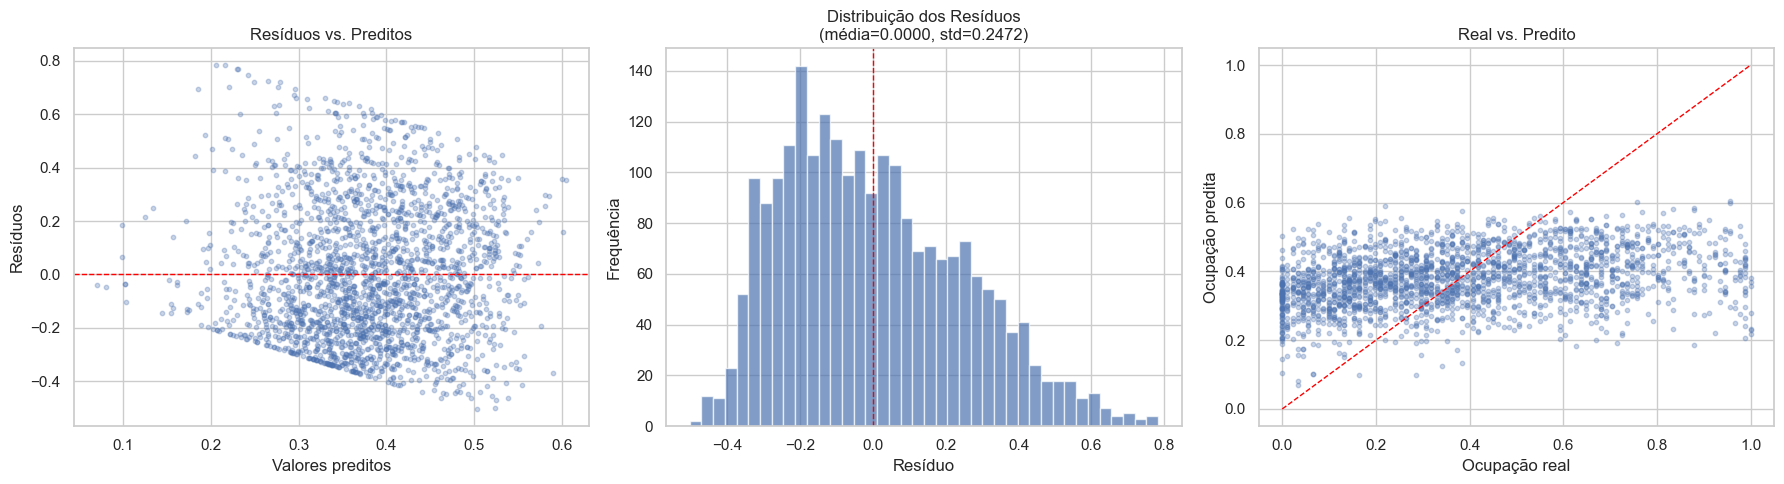


COEFICIENTES DO MODELO FINAL (OLS)
Feature                           Coef.    p-value  Signif.
----------------------------------------------------------------------
Intercept                       -1.0356     0.0000      ***
log_price                       -0.0457     0.0001      ***
review_scores_location           0.0115     0.0000      ***
log_number_of_reviews            0.0329     0.0000      ***
bairro_mean_ocup                 0.0098     0.0000      ***
estacao_outono                   0.0806     0.0000      ***
estacao_primavera                0.0312     0.0343        *
estacao_verao                    0.2032     0.0000      ***


In [61]:
# =============================================================
# CÉLULA 6 — Diagnósticos do modelo reduzido
# =============================================================

# Usar o OLS (resultados equivalentes, mais fácil de diagnosticar)
modelo_final = ols_red  # OLS reduzido da célula anterior

# 1. Resíduos vs Preditos
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

y_pred = modelo_final.predict(df).clip(0, 1)
residuos = df['occ_rate'] - y_pred

# 1a. Scatter resíduos vs preditos
axes[0].scatter(y_pred, residuos, alpha=0.3, s=10)
axes[0].axhline(0, ls='--', color='red', lw=1)
axes[0].set_xlabel('Valores preditos')
axes[0].set_ylabel('Resíduos')
axes[0].set_title('Resíduos vs. Preditos')

# 1b. Histograma dos resíduos
axes[1].hist(residuos, bins=40, edgecolor='white', alpha=0.7)
axes[1].axvline(0, ls='--', color='red', lw=1)
axes[1].set_xlabel('Resíduo')
axes[1].set_ylabel('Frequência')
axes[1].set_title(f'Distribuição dos Resíduos\n(média={residuos.mean():.4f}, std={residuos.std():.4f})')

# 1c. Real vs Predito
axes[2].scatter(df['occ_rate'], y_pred, alpha=0.3, s=10)
axes[2].plot([0, 1], [0, 1], ls='--', color='red', lw=1)
axes[2].set_xlabel('Ocupação real')
axes[2].set_ylabel('Ocupação predita')
axes[2].set_title('Real vs. Predito')

plt.tight_layout()
plt.savefig('diagnostico_modelo_reduzido.png', dpi=150)
plt.show()

# 2. Tabela de coeficientes formatada
print("\n" + "="*70)
print("COEFICIENTES DO MODELO FINAL (OLS)")
print("="*70)
print(f"{'Feature':<30} {'Coef.':>8} {'p-value':>10} {'Signif.':>8}")
print("-"*70)
for feat in modelo_final.params.index:
    coef = modelo_final.params[feat]
    pval = modelo_final.pvalues[feat]
    sig = '***' if pval < 0.001 else '**' if pval < 0.01 else '*' if pval < 0.05 else ''
    print(f"{feat:<30} {coef:>8.4f} {pval:>10.4f} {sig:>8}")


## 13. Exportação do modelo final


In [62]:
# =============================================================
# CÉLULA 7 — Exportar modelo e criar função predict_occ
# =============================================================

# 1. Salvar o modelo OLS (mais estável que o MixedLM singular)
modelo_bundle = {
    'model': ols_red,
    'features': features_reduzidas,
    'target': 'occ_rate',
    'divisor': 91,
    'tipo': 'OLS',
    'r2': ols_red.rsquared,
}

joblib.dump(modelo_bundle, 'modelo_ocupacao_final.pkl')
print("✅ Modelo salvo em modelo_ocupacao_final.pkl")

# 2. Função predict_occ
def predict_occ(context: dict, price: float, model_path='modelo_ocupacao_final.pkl'):
    """
    Prediz taxa de ocupação dado contexto do imóvel e preço.
    
    Args:
        context: dict com as features do imóvel 
                 (review_scores_location, log_number_of_reviews, 
                  bairro_mean_ocup, estacao_*)
        price:   preço da diária em R$
    
    Returns:
        float: taxa de ocupação predita (0 a 1)
    """
    bundle = joblib.load(model_path)
    model = bundle['model']
    
    # Monta a linha de predição
    row = context.copy()
    row['log_price'] = np.log1p(price)  # Mesmo log1p do ETL!
    
    # Garante que dummies de estação existam
    for est in ['estacao_outono', 'estacao_primavera', 'estacao_verao']:
        if est not in row:
            row[est] = 0
    
    # Predição
    df_pred = pd.DataFrame([row])
    pred = model.predict(df_pred)[0]
    
    return float(np.clip(pred, 0, 1))

# 3. Teste com um imóvel real
sample = df.iloc[0]
contexto_teste = {
    'review_scores_location': sample['review_scores_location'],
    'log_number_of_reviews': sample['log_number_of_reviews'],
    'bairro_mean_ocup': sample['bairro_mean_ocup'],
    'estacao_outono': 0,
    'estacao_primavera': 0,
    'estacao_verao': 1,  # verão
}

# Testar com diferentes preços
print("\n📊 Teste da curva de demanda (imóvel #1, verão):")
print(f"{'Preço (R$)':>12} {'Occ Rate':>10} {'Dias (91)':>10}")
print("-" * 35)

for preco in [100, 150, 200, 300, 500, 800, 1200]:
    occ = predict_occ(contexto_teste, preco)
    print(f"{preco:>12} {occ:>10.3f} {occ*91:>10.1f}")
    


✅ Modelo salvo em modelo_ocupacao_final.pkl

📊 Teste da curva de demanda (imóvel #1, verão):
  Preço (R$)   Occ Rate  Dias (91)
-----------------------------------
         100      0.605       55.1
         150      0.587       53.4
         200      0.574       52.2
         300      0.555       50.5
         500      0.532       48.4
         800      0.511       46.5
        1200      0.492       44.8


## 14. Figura 4 — Curva de demanda estimada por estação


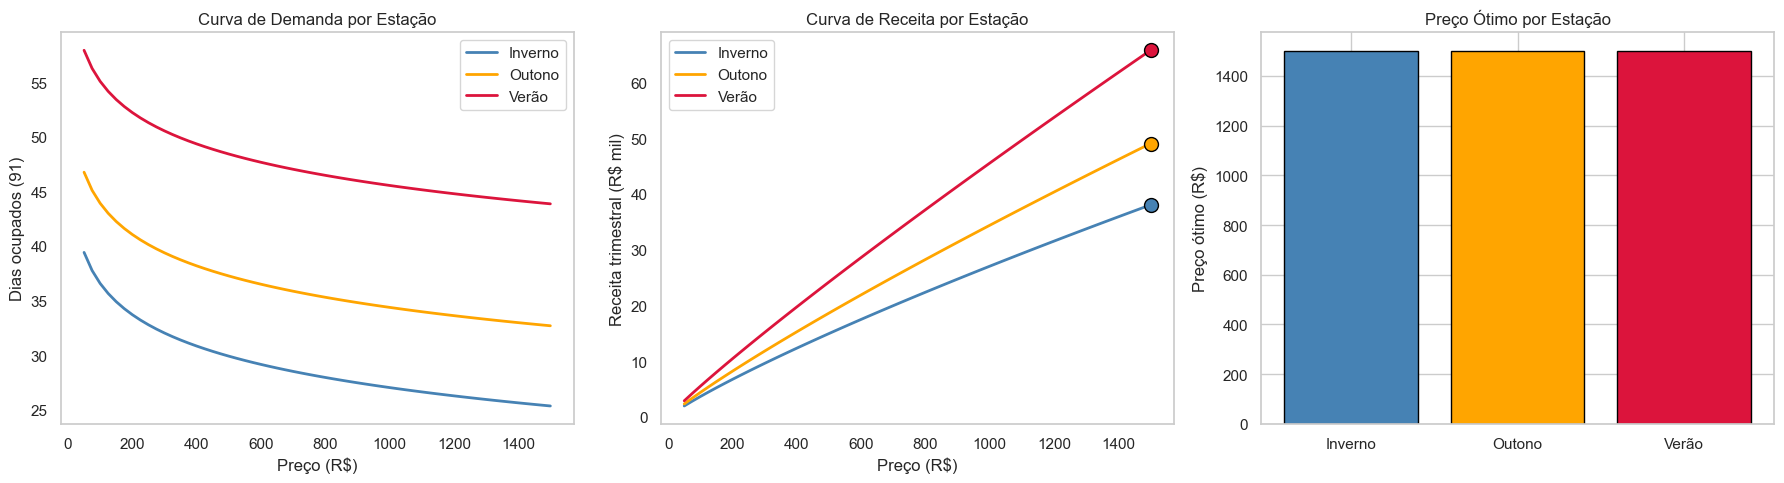

,estacao,preco_otimo_no_intervalo,ocupacao_prevista_dias,receita_prevista
0,Inverno,1500,25.36,38043.44
1,Outono,1500,32.70,49050.16
2,Verão,1500,43.86,65785.26


In [73]:
# =========================
# PARÂMETROS
# =========================
precos = np.arange(50, 1501, 25)

cenarios = {
    'Inverno': {'estacao_outono': 0, 'estacao_primavera': 0, 'estacao_verao': 0},
    'Outono':  {'estacao_outono': 1, 'estacao_primavera': 0, 'estacao_verao': 0},
    'Verão':   {'estacao_outono': 0, 'estacao_primavera': 0, 'estacao_verao': 1},
}

cores = {
    'Inverno': 'steelblue',
    'Outono': 'orange',
    'Verão': 'crimson'
}

# =========================
# CÁLCULO (SEM PLOT DUPLICADO)
# =========================
curva_receita_resumo = []

for nome, dummies in cenarios.items():
    contexto = {
        'review_scores_location': sample['review_scores_location'],
        'log_number_of_reviews': sample['log_number_of_reviews'],
        'bairro_mean_ocup': sample['bairro_mean_ocup'],
        **dummies,
    }

    occs = [predict_occ(contexto, p) for p in precos]
    dias = [o * 91 for o in occs]
    receitas = [p * d for p, d in zip(precos, dias)]

    idx_max = int(np.argmax(receitas))

    curva_receita_resumo.append({
        'estacao': nome,
        'preco_otimo_no_intervalo': int(precos[idx_max]),
        'ocupacao_prevista_dias': float(dias[idx_max]),
        'receita_prevista': float(receitas[idx_max]),
    })

# =========================
# FIGURA FINAL (ÚNICA)
# =========================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for nome, dummies in cenarios.items():
    contexto = {
        'review_scores_location': sample['review_scores_location'],
        'log_number_of_reviews': sample['log_number_of_reviews'],
        'bairro_mean_ocup': sample['bairro_mean_ocup'],
        **dummies
    }

    occs = [predict_occ(contexto, p) for p in precos]
    dias = [o * 91 for o in occs]
    receitas = [p * d for p, d in zip(precos, dias)]

    idx_max = int(np.argmax(receitas))

    # (1) Demanda
    axes[0].plot(precos, dias, label=nome, color=cores[nome], lw=2)

    # (2) Receita
    receitas_k = [r / 1000 for r in receitas]

    axes[1].plot(precos, receitas_k, label=nome, color=cores[nome], lw=2)
    axes[1].scatter(
        precos[idx_max],
        receitas_k[idx_max],
        color=cores[nome],
        s=100,
        edgecolor='black',
        zorder=5
    )

    # (3) Preço ótimo
    axes[2].bar(
        nome,
        precos[idx_max],
        color=cores[nome],
        edgecolor='black'
    )

# =========================
# FORMATAÇÃO
# =========================
axes[0].set_title('Curva de Demanda por Estação')
axes[0].set_xlabel('Preço (R$)')
axes[0].set_ylabel('Dias ocupados (91)')
axes[0].legend()
axes[0].grid(False)

axes[1].set_title('Curva de Receita por Estação')
axes[1].set_xlabel('Preço (R$)')
axes[1].set_ylabel('Receita trimestral (R$ mil)')
axes[1].legend()
axes[1].grid(False)

axes[2].set_title('Preço Ótimo por Estação')
axes[2].set_ylabel('Preço ótimo (R$)')

plt.tight_layout()
plt.savefig('curva_demanda_receita.png', dpi=150, bbox_inches='tight')
plt.show()

# =========================
# TABELA FINAL
# =========================
display(pd.DataFrame(curva_receita_resumo).round(2))


## 15. Definição dos algoritmos MAB


In [64]:
# =============================================================
# CÉLULA 9 — Algoritmos Multi-Armed Bandits
# =============================================================
# Três estratégias de precificação dinâmica:
#   1. ε-Greedy: explora aleatoriamente com probabilidade ε
#   2. UCB (Upper Confidence Bound): explora braços incertos
#   3. Thompson Sampling: amostra de distribuição posterior

import numpy as np

class EpsilonGreedy:
    """ε-Greedy: escolhe o melhor braço com prob (1-ε), aleatório com prob ε."""
    
    def __init__(self, n_arms, epsilon=0.1):
        self.n_arms = n_arms
        self.epsilon = epsilon
        self.counts = np.zeros(n_arms)       # vezes que cada braço foi puxado
        self.values = np.zeros(n_arms)       # recompensa média de cada braço
    
    def select_arm(self):
        if np.random.random() < self.epsilon:
            return np.random.randint(self.n_arms)  # explora
        return np.argmax(self.values)               # explota
    
    def update(self, arm, reward):
        self.counts[arm] += 1
        n = self.counts[arm]
        self.values[arm] += (reward - self.values[arm]) / n  # média incremental


class UCB:
    """Upper Confidence Bound: escolhe o braço com maior limite superior."""
    
    def __init__(self, n_arms, c=2.0):
        self.n_arms = n_arms
        self.c = c                           # parâmetro de exploração
        self.counts = np.zeros(n_arms)
        self.values = np.zeros(n_arms)
        self.t = 0                           # rodada atual
    
    def select_arm(self):
        self.t += 1
        # Primeiro: testar cada braço pelo menos 1 vez
        for arm in range(self.n_arms):
            if self.counts[arm] == 0:
                return arm
        
        # Depois: braço com maior UCB
        ucb_values = self.values + self.c * np.sqrt(
            np.log(self.t) / self.counts
        )
        return np.argmax(ucb_values)
    
    def update(self, arm, reward):
        self.counts[arm] += 1
        n = self.counts[arm]
        self.values[arm] += (reward - self.values[arm]) / n


class ThompsonSampling:
    """Thompson Sampling: amostra de distribuição Normal-Gamma posterior."""
    
    def __init__(self, n_arms):
        self.n_arms = n_arms
        # Parâmetros da posterior Normal-Gamma (prior vago)
        self.mu = np.zeros(n_arms)           # média estimada
        self.lambda_ = np.ones(n_arms)       # precisão da média
        self.alpha = np.ones(n_arms)         # shape da Gamma
        self.beta = np.ones(n_arms)          # rate da Gamma
    
    def select_arm(self):
        samples = np.zeros(self.n_arms)
        for arm in range(self.n_arms):
            # Amostra precisão da Gamma
            tau = np.random.gamma(self.alpha[arm], 1.0 / self.beta[arm])
            # Amostra média da Normal
            mu_sample = np.random.normal(
                self.mu[arm], 
                1.0 / np.sqrt(self.lambda_[arm] * tau)
            )
            samples[arm] = mu_sample
        return np.argmax(samples)
    
    def update(self, arm, reward):
        # Atualização Bayesiana da Normal-Gamma
        old_lambda = self.lambda_[arm]
        old_mu = self.mu[arm]
        
        self.lambda_[arm] += 1
        self.mu[arm] = (old_lambda * old_mu + reward) / self.lambda_[arm]
        self.alpha[arm] += 0.5
        self.beta[arm] += 0.5 * old_lambda * (reward - old_mu)**2 / self.lambda_[arm]


print("✅ Algoritmos definidos: ε-Greedy, UCB, Thompson Sampling")
print(f"   Cada algoritmo tem: select_arm() e update(arm, reward)")


✅ Algoritmos definidos: ε-Greedy, UCB, Thompson Sampling
   Cada algoritmo tem: select_arm() e update(arm, reward)


## 16. Simulação MAB — cenário estacionário (verão)


In [65]:
# =============================================================
# CÉLULA 10 — Simulação MAB de precificação dinâmica
# =============================================================

# 1. Carregar modelo UMA VEZ (evita recarregar a cada chamada)
bundle = joblib.load('modelo_ocupacao_final.pkl')
modelo_carregado = bundle['model']

def predict_occ_fast(contexto, preco):
    """Prediz ocupação sem recarregar o modelo do disco."""
    row = contexto.copy()
    row['log_price'] = np.log1p(preco)
    for est in ['estacao_outono', 'estacao_primavera', 'estacao_verao']:
        if est not in row:
            row[est] = 0
    df_pred = pd.DataFrame([row])
    return float(np.clip(modelo_carregado.predict(df_pred)[0], 0, 1))

# 2. Definir os "braços" — faixas de preço
precos_bracos = [100, 150, 200, 250, 300, 400, 500, 650, 800, 1000]
n_arms = len(precos_bracos)
print(f"Braços (faixas de preço): {precos_bracos}")
print(f"Número de braços: {n_arms}\n")

# 3. Parâmetros da simulação
N_RODADAS = 1000       # decisões de preço por simulação
N_SIMULACOES = 50      # repetições para estabilidade estatística
np.random.seed(42)

# 4. Selecionar 10 imóveis aleatórios para simulação
sample_ids = df['listing_id'].unique().copy()
np.random.shuffle(sample_ids)
imoveis_sim = sample_ids[:10]

# 5. Pré-computar contextos e ocupações base
#    (evita chamar predict_occ 150.000 vezes no loop)
print("Pré-computando ocupações base...")
contextos_sim = []
for imovel_id in imoveis_sim:
    row = df[df['listing_id'] == imovel_id].iloc[0]
    ctx = {
        'review_scores_location': row['review_scores_location'],
        'log_number_of_reviews': row['log_number_of_reviews'],
        'bairro_mean_ocup': row['bairro_mean_ocup'],
        'estacao_outono': 0,
        'estacao_primavera': 0,
        'estacao_verao': 1,  # cenário: verão
    }
    contextos_sim.append(ctx)

# Tabela pré-computada: occ_base[imovel_idx, arm_idx]
occ_base = np.zeros((len(imoveis_sim), n_arms))
for i, ctx in enumerate(contextos_sim):
    for j, preco in enumerate(precos_bracos):
        occ_base[i, j] = predict_occ_fast(ctx, preco)

print("✅ Ocupações pré-computadas.\n")

# 6. Rodar simulação
print("Rodando simulações...")
resultados_por_algo = {
    'ε-Greedy': [],
    'UCB': [],
    'Thompson Sampling': [],
}

# Guardar braços escolhidos de todas as simulações
contagem_bracos = {nome: np.zeros(n_arms) for nome in resultados_por_algo}

for sim in range(N_SIMULACOES):
    # Escolher imóvel aleatório
    imovel_idx = np.random.randint(len(imoveis_sim))
    
    # Inicializar algoritmos
    algos = {
        'ε-Greedy': EpsilonGreedy(n_arms, epsilon=0.1),
        'UCB': UCB(n_arms, c=2.0),
        'Thompson Sampling': ThompsonSampling(n_arms),
    }
    
    # Histórico de receita acumulada
    historicos = {nome: np.zeros(N_RODADAS) for nome in algos}
    
    # Contagem de braços por simulação
    bracos_sim = {nome: np.zeros(n_arms) for nome in algos}
    
    for t in range(N_RODADAS):
        for nome, algo in algos.items():
            # Escolher braço (preço)
            arm = algo.select_arm()
            preco = precos_bracos[arm]
            
            # Recompensa: ocupação pré-computada + ruído estocástico
            occ = np.clip(occ_base[imovel_idx, arm] + np.random.normal(0, 0.08), 0, 1)
            reward = preco * occ * 91 / 1000
            
            # Atualizar algoritmo
            algo.update(arm, reward)
            
            # Registrar
            bracos_sim[nome][arm] += 1
            historicos[nome][t] = (historicos[nome][t-1] if t > 0 else 0) + reward
    
    for nome in algos:
        resultados_por_algo[nome].append(historicos[nome])
        contagem_bracos[nome] += bracos_sim[nome]
    
    if (sim + 1) % 10 == 0:
        print(f"  Simulação {sim+1}/{N_SIMULACOES}")

# 7. Calcular médias e intervalos de confiança
print("\nCalculando estatísticas...\n")

media_por_algo = {}
ic_inf = {}
ic_sup = {}

for nome in resultados_por_algo:
    matriz = np.array(resultados_por_algo[nome])
    media_por_algo[nome] = matriz.mean(axis=0)
    ic_inf[nome] = np.percentile(matriz, 10, axis=0)
    ic_sup[nome] = np.percentile(matriz, 90, axis=0)

# 8. Resultados finais
print("=" * 65)
print("RESULTADO — Receita acumulada após 1.000 rodadas (R$ mil)")
print("=" * 65)
print(f"{'Algoritmo':<20} {'Média':>10} {'P10':>10} {'P90':>10}")
print("-" * 65)
for nome in resultados_por_algo:
    m = media_por_algo[nome][-1]
    lo = ic_inf[nome][-1]
    hi = ic_sup[nome][-1]
    print(f"{nome:<20} {m:>10.1f} {lo:>10.1f} {hi:>10.1f}")

# 9. Braços mais escolhidos (acumulado de todas as simulações)
print(f"\n{'=' * 65}")
print("BRAÇOS MAIS ESCOLHIDOS (acumulado de todas as simulações)")
print("=" * 65)

for nome in resultados_por_algo:
    total = contagem_bracos[nome].sum()
    print(f"\n{nome}:")
    for i, (preco, count) in enumerate(zip(precos_bracos, contagem_bracos[nome])):
        pct = count / total * 100
        bar = '█' * int(pct / 2)
        print(f"  R${preco:>5} | {count:>5.0f}x ({pct:>5.1f}%) {bar}")

print("\n✅ Simulação concluída!")


Braços (faixas de preço): [100, 150, 200, 250, 300, 400, 500, 650, 800, 1000]
Número de braços: 10

Pré-computando ocupações base...
✅ Ocupações pré-computadas.

Rodando simulações...
  Simulação 10/50
  Simulação 20/50
  Simulação 30/50
  Simulação 40/50
  Simulação 50/50

Calculando estatísticas...

RESULTADO — Receita acumulada após 1.000 rodadas (R$ mil)
Algoritmo                 Média        P10        P90
-----------------------------------------------------------------
ε-Greedy                37223.7    28393.8    43501.4
UCB                     40304.1    30553.2    46207.6
Thompson Sampling       35321.1    27839.6    42975.6

BRAÇOS MAIS ESCOLHIDOS (acumulado de todas as simulações)

ε-Greedy:
  R$  100 |  1012x (  2.0%) █
  R$  150 |   553x (  1.1%) 
  R$  200 |   592x (  1.2%) 
  R$  250 |   549x (  1.1%) 
  R$  300 |   574x (  1.1%) 
  R$  400 |   763x (  1.5%) 
  R$  500 |   921x (  1.8%) 
  R$  650 |  1350x (  2.7%) █
  R$  800 |  3856x (  7.7%) ███
  R$ 1000 | 39830x ( 

,Algoritmo,Receita_media_R$_mil,P10_R$_mil,P90_R$_mil,Braco_preferido,Concentracao_pct
0,ε-Greedy,37223.7,28393.8,43501.4,R$ 1000,79.7
1,UCB,40304.1,30553.2,46207.6,R$ 1000,94.4
2,Thompson Sampling,35321.1,27839.6,42975.6,R$ 1000,51.7


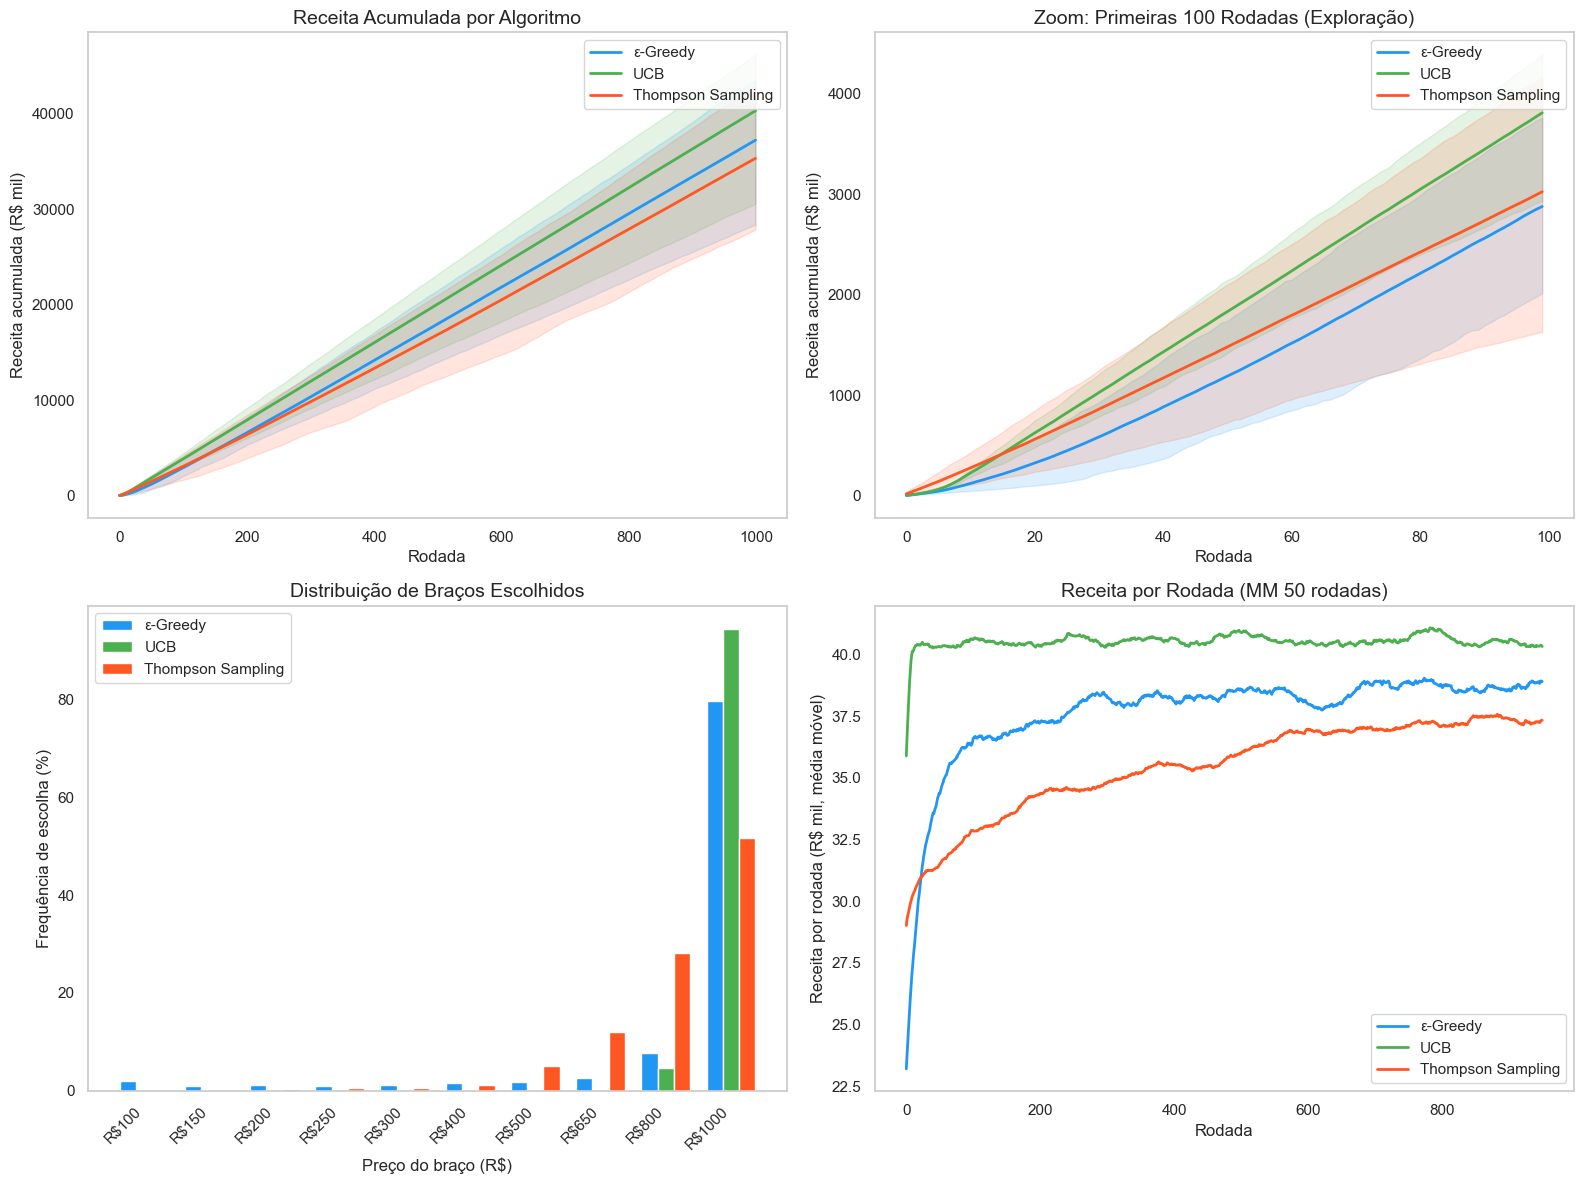

In [66]:
# =========================
# TABELA RESUMO
# =========================
tabela_8 = pd.DataFrame([
    {
        'Algoritmo': nome,
        'Receita_media_R$_mil': media_por_algo[nome][-1],
        'P10_R$_mil': ic_inf[nome][-1],
        'P90_R$_mil': ic_sup[nome][-1],
        'Braco_preferido': f"R$ {precos_bracos[int(np.argmax(contagem_bracos[nome]))]}",
        'Concentracao_pct': contagem_bracos[nome].max() / contagem_bracos[nome].sum() * 100,
    }
    for nome in resultados_por_algo
]).round(1)

display(tabela_8)

# =========================
# CORES PADRÃO
# =========================
cores = {
    'ε-Greedy': '#2196F3',
    'UCB': '#4CAF50',
    'Thompson Sampling': '#FF5722',
}

# =========================
# FIGURA FINAL CONSOLIDADA
# =========================
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# =========================
# (1) Receita acumulada
# =========================
ax = axes[0, 0]

for nome in resultados_por_algo:
    ax.plot(
        media_por_algo[nome],
        label=nome,
        color=cores[nome],
        lw=2
    )
    ax.fill_between(
        range(N_RODADAS),
        ic_inf[nome],
        ic_sup[nome],
        alpha=0.15,
        color=cores[nome]
    )

ax.set_xlabel('Rodada', fontsize=12)
ax.set_ylabel('Receita acumulada (R$ mil)', fontsize=12)
ax.set_title('Receita Acumulada por Algoritmo', fontsize=14)
ax.legend(fontsize=11)
ax.grid(False)

# =========================
# (2) Zoom primeiras 100
# =========================
ax = axes[0, 1]

for nome in resultados_por_algo:
    ax.plot(
        media_por_algo[nome][:100],
        label=nome,
        color=cores[nome],
        lw=2
    )
    ax.fill_between(
        range(100),
        ic_inf[nome][:100],
        ic_sup[nome][:100],
        alpha=0.15,
        color=cores[nome]
    )

ax.set_xlabel('Rodada', fontsize=12)
ax.set_ylabel('Receita acumulada (R$ mil)', fontsize=12)
ax.set_title('Zoom: Primeiras 100 Rodadas (Exploração)', fontsize=14)
ax.legend(fontsize=11)
ax.grid(False)

# =========================
# (3) Distribuição de braços
# =========================
ax = axes[1, 0]

x = np.arange(n_arms)
largura = 0.25

for idx, nome in enumerate(resultados_por_algo):
    total = contagem_bracos[nome].sum()
    pcts = contagem_bracos[nome] / total * 100

    ax.bar(
        x + idx * largura,
        pcts,
        largura,
        label=nome,
        color=cores[nome],
        edgecolor='white'
    )

ax.set_xlabel('Preço do braço (R$)', fontsize=12)
ax.set_ylabel('Frequência de escolha (%)', fontsize=12)
ax.set_title('Distribuição de Braços Escolhidos', fontsize=14)

ax.set_xticks(x + largura)
ax.set_xticklabels(
    [f'R${p}' for p in precos_bracos],
    rotation=45,
    ha='right'
)

ax.legend(fontsize=11)
ax.grid(False)

# =========================
# (4) Receita por rodada (média móvel)
# =========================
ax = axes[1, 1]

janela = 50

for nome in resultados_por_algo:
    receita_rodada = np.diff(media_por_algo[nome], prepend=0)

    media_movel = np.convolve(
        receita_rodada,
        np.ones(janela) / janela,
        mode='valid'
    )

    ax.plot(
        media_movel,
        label=nome,
        color=cores[nome],
        lw=2
    )

ax.set_xlabel('Rodada', fontsize=12)
ax.set_ylabel('Receita por rodada (R$ mil, média móvel)', fontsize=12)
ax.set_title(f'Receita por Rodada (MM {janela} rodadas)', fontsize=14)

ax.legend(fontsize=11)
ax.grid(False)

# =========================
# FINALIZAÇÃO
# =========================
plt.tight_layout()
plt.savefig(
    'simulacao_mab_resultados.png',
    dpi=150,
    bbox_inches='tight'
)
plt.show()

## 17. Simulação MAB — cenário multi-estação


In [67]:
# =============================================================
# CÉLULA 12 — Simulação MAB multi-estação
# =============================================================
# Compara o desempenho dos algoritmos quando o contexto muda
# entre estações (ambiente não-estacionário).

print("="*65)
print("SIMULAÇÃO MULTI-ESTAÇÃO")
print("="*65)

# 1. Definir cenários sazonais
estacoes = {
    'Inverno':   {'estacao_outono': 0, 'estacao_primavera': 0, 'estacao_verao': 0},
    'Primavera': {'estacao_outono': 0, 'estacao_primavera': 1, 'estacao_verao': 0},
    'Verão':     {'estacao_outono': 0, 'estacao_primavera': 0, 'estacao_verao': 1},
    'Outono':    {'estacao_outono': 1, 'estacao_primavera': 0, 'estacao_verao': 0},
}

# 2. Pré-computar ocupações por estação
#    occ_estacao[estacao][imovel_idx, arm_idx]
print("Pré-computando ocupações por estação...")
occ_estacao = {}
for nome_est, dummies in estacoes.items():
    occ_est = np.zeros((len(imoveis_sim), n_arms))
    for i, ctx_base in enumerate(contextos_sim):
        ctx = {k: v for k, v in ctx_base.items() 
               if not k.startswith('estacao_')}
        ctx.update(dummies)
        for j, preco in enumerate(precos_bracos):
            occ_est[i, j] = predict_occ_fast(ctx, preco)
    occ_estacao[nome_est] = occ_est
print("✅ Ocupações pré-computadas para 4 estações.\n")

# 3. Simulação: cada simulação passa por 4 estações (250 rodadas cada)
N_RODADAS_TOTAL = 1000  # 250 por estação
N_SIMULACOES = 50
RODADAS_POR_ESTACAO = N_RODADAS_TOTAL // len(estacoes)
np.random.seed(42)

ordem_estacoes = ['Inverno', 'Primavera', 'Verão', 'Outono']

resultados_multi = {nome: [] for nome in ['ε-Greedy', 'UCB', 'Thompson Sampling']}
contagem_multi = {nome: {est: np.zeros(n_arms) for est in ordem_estacoes} 
                  for nome in resultados_multi}

print(f"Rodando: {N_RODADAS_TOTAL} rodadas ({RODADAS_POR_ESTACAO}/estação) × {N_SIMULACOES} simulações")
print(f"Ordem: {' → '.join(ordem_estacoes)}\n")

for sim in range(N_SIMULACOES):
    imovel_idx = np.random.randint(len(imoveis_sim))
    
    algos = {
        'ε-Greedy': EpsilonGreedy(n_arms, epsilon=0.1),
        'UCB': UCB(n_arms, c=2.0),
        'Thompson Sampling': ThompsonSampling(n_arms),
    }
    
    historicos = {nome: np.zeros(N_RODADAS_TOTAL) for nome in algos}
    t_global = 0
    
    for est_nome in ordem_estacoes:
        occ_atual = occ_estacao[est_nome]
        
        for t_local in range(RODADAS_POR_ESTACAO):
            for nome, algo in algos.items():
                arm = algo.select_arm()
                preco = precos_bracos[arm]
                
                occ = np.clip(occ_atual[imovel_idx, arm] + np.random.normal(0, 0.08), 0, 1)
                reward = preco * occ * 91 / 1000
                
                algo.update(arm, reward)
                contagem_multi[nome][est_nome][arm] += 1
                historicos[nome][t_global] = (
                    historicos[nome][t_global - 1] if t_global > 0 else 0
                ) + reward
            
            t_global += 1
    
    for nome in algos:
        resultados_multi[nome].append(historicos[nome])
    
    if (sim + 1) % 10 == 0:
        print(f"  Simulação {sim+1}/{N_SIMULACOES}")

# 4. Estatísticas
media_multi = {}
ic_inf_multi = {}
ic_sup_multi = {}
for nome in resultados_multi:
    matriz = np.array(resultados_multi[nome])
    media_multi[nome] = matriz.mean(axis=0)
    ic_inf_multi[nome] = np.percentile(matriz, 10, axis=0)
    ic_sup_multi[nome] = np.percentile(matriz, 90, axis=0)

# 5. Resultados
print(f"\n{'='*65}")
print("RESULTADO — Receita acumulada multi-estação (R$ mil)")
print("="*65)
print(f"{'Algoritmo':<20} {'Média':>10} {'P10':>10} {'P90':>10}")
print("-"*65)

for nome in resultados_multi:
    m = media_multi[nome][-1]
    lo = ic_inf_multi[nome][-1]
    hi = ic_sup_multi[nome][-1]
    print(f"{nome:<20} {m:>10.1f} {lo:>10.1f} {hi:>10.1f}")

# 6. Braços por estação
print(f"\n{'='*65}")
print("BRAÇO PREFERIDO POR ESTAÇÃO")
print("="*65)
for nome in resultados_multi:
    print(f"\n{nome}:")
    for est in ordem_estacoes:
        total = contagem_multi[nome][est].sum()
        top_arm = np.argmax(contagem_multi[nome][est])
        top_pct = contagem_multi[nome][est][top_arm] / total * 100
        print(f"  {est:<12} → R${precos_bracos[top_arm]:>5} ({top_pct:.1f}%)")


SIMULAÇÃO MULTI-ESTAÇÃO
Pré-computando ocupações por estação...
✅ Ocupações pré-computadas para 4 estações.

Rodando: 1000 rodadas (250/estação) × 50 simulações
Ordem: Inverno → Primavera → Verão → Outono

  Simulação 10/50
  Simulação 20/50
  Simulação 30/50
  Simulação 40/50
  Simulação 50/50

RESULTADO — Receita acumulada multi-estação (R$ mil)
Algoritmo                 Média        P10        P90
-----------------------------------------------------------------
ε-Greedy                27838.7    24594.9    33187.0
UCB                     29671.3    26445.6    34956.3
Thompson Sampling       27159.1    22222.0    31538.4

BRAÇO PREFERIDO POR ESTAÇÃO

ε-Greedy:
  Inverno      → R$ 1000 (47.1%)
  Primavera    → R$ 1000 (81.7%)
  Verão        → R$ 1000 (82.8%)
  Outono       → R$ 1000 (82.2%)

UCB:
  Inverno      → R$ 1000 (79.2%)
  Primavera    → R$ 1000 (84.0%)
  Verão        → R$ 1000 (84.0%)
  Outono       → R$ 1000 (84.0%)

Thompson Sampling:
  Inverno      → R$ 1000 (30.4%)
  Pri

,Algoritmo,Receita_media_R$_mil,P10_R$_mil,P90_R$_mil,Queda_vs_cenario_fixo_pct
0,ε-Greedy,27838.7,24594.9,33187.0,-25.2
1,UCB,29671.3,26445.6,34956.3,-26.4
2,Thompson Sampling,27159.1,22222.0,31538.4,-23.1


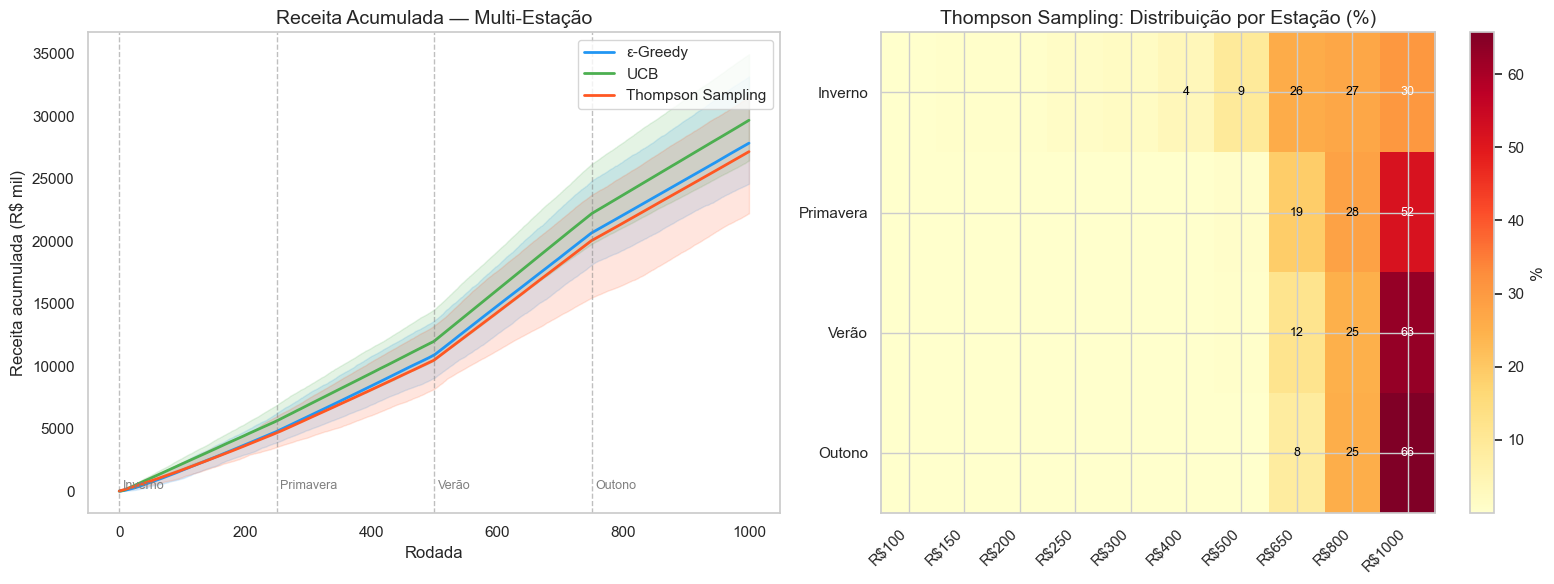

In [68]:

# =========================
# TABELA RESUMO
# =========================
queda_pct = {
    nome: (media_multi[nome][-1] / media_por_algo[nome][-1] - 1) * 100
    for nome in resultados_multi
}

tabela_9 = pd.DataFrame([
    {
        'Algoritmo': nome,
        'Receita_media_R$_mil': media_multi[nome][-1],
        'P10_R$_mil': ic_inf_multi[nome][-1],
        'P90_R$_mil': ic_sup_multi[nome][-1],
        'Queda_vs_cenario_fixo_pct': queda_pct[nome],
    }
    for nome in resultados_multi
]).round(1)

display(tabela_9)

# =========================
# MATRIZ DO HEATMAP (TS)
# =========================
ts_matrix = np.zeros((len(ordem_estacoes), n_arms))

for i, est in enumerate(ordem_estacoes):
    total = contagem_multi['Thompson Sampling'][est].sum()
    ts_matrix[i] = contagem_multi['Thompson Sampling'][est] / total * 100

# =========================
# FIGURA FINAL CONSOLIDADA
# =========================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# =========================
# (1) Receita acumulada multi-estação
# =========================
ax = axes[0]

for nome in resultados_multi:
    ax.plot(
        media_multi[nome],
        label=nome,
        color=cores[nome],
        lw=2
    )
    ax.fill_between(
        range(N_RODADAS_TOTAL),
        ic_inf_multi[nome],
        ic_sup_multi[nome],
        alpha=0.15,
        color=cores[nome]
    )

# Linhas de troca de estação
for i, est in enumerate(ordem_estacoes):
    x_pos = i * RODADAS_POR_ESTACAO

    ax.axvline(
        x_pos,
        ls='--',
        color='gray',
        alpha=0.5,
        lw=1
    )

    ax.text(
        x_pos + 5,
        ax.get_ylim()[0] + (ax.get_ylim()[1] - ax.get_ylim()[0]) * 0.05,
        est,
        fontsize=9,
        color='gray'
    )

ax.set_xlabel('Rodada', fontsize=12)
ax.set_ylabel('Receita acumulada (R$ mil)', fontsize=12)
ax.set_title('Receita Acumulada — Multi-Estação', fontsize=14)
ax.legend(fontsize=11)
ax.grid(False)

# =========================
# (2) Heatmap — Thompson Sampling
# =========================
ax = axes[1]

im = ax.imshow(
    ts_matrix,
    cmap='YlOrRd',
    aspect='auto'
)

ax.set_xticks(range(n_arms))
ax.set_xticklabels(
    [f'R${p}' for p in precos_bracos],
    rotation=45,
    ha='right'
)

ax.set_yticks(range(len(ordem_estacoes)))
ax.set_yticklabels(ordem_estacoes)

ax.set_title('Thompson Sampling: Distribuição por Estação (%)', fontsize=14)

# Colorbar
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('%')

# Anotações dentro do heatmap
for i in range(len(ordem_estacoes)):
    for j in range(n_arms):
        val = ts_matrix[i, j]

        if val > 3:
            ax.text(
                j,
                i,
                f'{val:.0f}',
                ha='center',
                va='center',
                fontsize=9,
                color='white' if val > 30 else 'black'
            )

# =========================
# FINALIZAÇÃO
# =========================
plt.tight_layout()
plt.savefig(
    'simulacao_mab_multi_estacao.png',
    dpi=150,
    bbox_inches='tight'
)
plt.show()

## 18. Resumo final da reprodução


In [69]:
resumo_reproducao = {
    'amostra': {
        'n_imoveis': int(df_feature_buinding['listing_id'].nunique()),
        'n_observacoes': int(len(df_feature_buinding)),
        'ocupacao_media_dias': float(df_feature_buinding['total_ocupacy_3'].mean()),
    },
    'pca': {
        'kmo': float(kmo_model),
        'bartlett_stat': float(bartlett_stat),
        'bartlett_p': float(bartlett_p),
        'variancia_explicada': float(pca.explained_variance_ratio_[0]),
    },
    'modelo_final': {
        'tipo': 'OLS',
        'r2': float(ols_red.rsquared),
        'mae_dias': float(mae_ols * 91),
        'rmse_dias': float(rmse_ols * 91),
    },
    'cenario_estacionario': {nome: float(media_por_algo[nome][-1]) for nome in media_por_algo},
    'cenario_multi_estacao': {nome: float(media_multi[nome][-1]) for nome in media_multi},
    'figuras': [
        'Histogramas Antes e depois.png',
        'correlacao_subnotas.png',
        'diagnostico_modelo_reduzido.png',
        'curva_demanda_estimada.png',
        'curva_demanda_receita.png',
        'simulacao_mab_receita_estacionario.png',
        'simulacao_mab_bracos_estacionario.png',
        'simulacao_mab_resultados.png',
        'simulacao_mab_receita_multi_estacao.png',
        'simulacao_mab_multi_estacao.png',
        'heatmap_thompson_multi_estacao.png',
    ],
    'validacao_tabela6': 'validacao_tabela6.json',
}
with open('resultados_reproducao_publica.json', 'w', encoding='utf-8') as fp:
    json.dump(resumo_reproducao, fp, ensure_ascii=False, indent=2)
print(json.dumps(resumo_reproducao, ensure_ascii=False, indent=2))


{
  "amostra": {
    "n_imoveis": 571,
    "n_observacoes": 2284,
    "ocupacao_media_dias": 34.595446584938706
  },
  "pca": {
    "kmo": 0.8816989859557294,
    "bartlett_stat": 2116.691427670131,
    "bartlett_p": 0.0,
    "variancia_explicada": 0.647111021469792
  },
  "modelo_final": {
    "tipo": "OLS",
    "r2": 0.09975508877710515,
    "mae_dias": 18.556775284111563,
    "rmse_dias": 22.488204806248802
  },
  "cenario_estacionario": {
    "ε-Greedy": 37223.673619989386,
    "UCB": 40304.07925379537,
    "Thompson Sampling": 35321.055990979505
  },
  "cenario_multi_estacao": {
    "ε-Greedy": 27838.686872574057,
    "UCB": 29671.277180128494,
    "Thompson Sampling": 27159.07265973963
  },
  "figuras": [
    "Histogramas Antes e depois.png",
    "correlacao_subnotas.png",
    "diagnostico_modelo_reduzido.png",
    "curva_demanda_estimada.png",
    "curva_demanda_receita.png",
    "simulacao_mab_receita_estacionario.png",
    "simulacao_mab_bracos_estacionario.png",
    "simulaca